<a href="https://colab.research.google.com/github/sirius70/NLP_HW4/blob/main/IE7275_Module8_STUDENT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **IE7275 Data Mining in Engineering**
### -- STUDENT VERSION --

---
#### **Guidelines for Completing and Submitting This Notebook**

Please follow these instructions carefully. Completing all parts of this notebook is required to receive full credit:

#### **You must:**
- **Answer all questions** and reflection tasks using your own words.
- **Summarize every reflection task** clearly and completely.
- **Fill out all missing code cells** — do not leave any code blocks empty.
- **Run your notebook** to ensure that all outputs and visualizations are generated and visible.
- **Convert your completed notebook** to **PDF** or **HTML** format before submission.
- **Submit the file to Canvas** before the deadline.

#### **Academic Integrity Reminder**:
- You must complete this notebook individually.
- Do not copy answers or code from classmates, online sources, or use tools like **ChatGPT** or other **AI writing or code generation tools**.
- Keep in mind that if you use such tools, your answer may be **identical or highly similar** to others who do the same — in this case, we will treat it as copying and apply a **50% penalty** to your assignment grade.

By submitting this notebook, you confirm that all work is your own and that you have followed these guidelines.


---



## **Module 8: Machine Learning Model Evaluation and Comparison**
---

#### **Module 8.1: Introduction to Model Evaluation**

Model evaluation is a critical step in the machine learning process that assesses how well a model performs on unseen data. The main goal is to ensure that the model not only fits the training data but also generalizes well to new, real-world data.

Key points include:  
- **Why evaluation matters:** Without proper evaluation, a model may overfit or underfit, leading to poor predictions in practice.  
- **Generalization:** The ability of a model to perform accurately on new, unseen data is crucial for reliable deployment.  
- **Validation techniques:** Splitting data into training and testing sets or using cross-validation methods to obtain unbiased performance estimates.  
- **Avoiding pitfalls:** Understanding common issues like data leakage, biased sampling, and overly optimistic metrics.

In this sub-module, you will learn the foundations of model evaluation, the role of validation, and how to interpret evaluation results to guide model development.

---

#### **Exercise 1: Train-Test Split and Basic Model Evaluation**

**Objective:**  
Learn to split a dataset into training and testing subsets and evaluate a machine learning model's performance on unseen data using standard metrics.

**Instructions:**

1. **Load a standard dataset** (e.g., the Iris dataset for classification or Boston Housing for regression).

2. **Split the data** into training (70%) and testing (30%) sets using `train_test_split`.

3. **Train a simple model** (e.g., logistic regression for classification or linear regression for regression) on the training set.

4. **Evaluate the model’s performance** on the testing set using appropriate metrics:
   - Classification: accuracy, precision, recall, F1-score  
   - Regression: mean squared error (MSE), R-squared

5. **Discuss the importance of testing on unseen data** and how the metrics reflect model performance.

---


In [1]:
# Import necessary libraries
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# Step 1: Load the Iris dataset
iris = load_iris()
X = iris.data
y = iris.target

# Step 2: Split data into training (70%) and testing (30%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Step 3: Train a logistic regression model
model = LogisticRegression(max_iter=200)
model.fit(X_train, y_train)

# Step 4: Predict on test data
y_pred = model.predict(X_test)


In [2]:
# Step 5: Evaluate model performance
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision (weighted): {precision:.4f}")
print(f"Recall (weighted): {recall:.4f}")
print(f"F1-score (weighted): {f1:.4f}")


Accuracy: 0.9333
Precision (weighted): 0.9345
Recall (weighted): 0.9333
F1-score (weighted): 0.9333


In [3]:
# Optional: Detailed classification report
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        15
           1       0.88      0.93      0.90        15
           2       0.93      0.87      0.90        15

    accuracy                           0.93        45
   macro avg       0.93      0.93      0.93        45
weighted avg       0.93      0.93      0.93        45



---

#### **In-Class Reflection: Exercise Summary**

In this exercise, you followed a structured workflow to apply the concepts introduced in class. Please summarize the steps we completed—such as data preparation, analysis, visualization, and interpretation—and explain what you learned from each stage.  

Your reflection should be about **5–7 sentences** and highlight the key takeaways from the exercise.  

> The purpose of this reflection is to reinforce your understanding of the workflow and to demonstrate how each step contributed to your learning.  

---

This exercise followed a clear step-by-step process to understand how a machine learning model is evaluated. First, the dataset was loaded and prepared, which helped in understanding the features and target values being used. Then, the data was split into training and testing sets, showing why it is important to test the model on unseen data instead of only relying on training results. A logistic regression model was trained on the training data, which demonstrated how models learn patterns from data. After that, predictions were made on the test set, and different evaluation metrics like accuracy, precision, recall, and F1-score were calculated. These metrics helped in understanding how well the model performed from different perspectives, not just overall accuracy. Overall, the exercise showed the importance of proper evaluation to ensure the model generalizes well and gives reliable results.

#### **Exercise 2: Cross-Validation Techniques and Performance Estimation**

**Objective:**  
Understand how to use **k-fold cross-validation** to obtain robust and unbiased estimates of model performance, reducing variance caused by a single train-test split.

**Instructions:**

1. **Load a standard dataset** (e.g., the Iris dataset for classification).

2. **Select a simple model** (e.g., logistic regression).

3. **Perform k-fold cross-validation** (e.g., k=5) using `cross_val_score` or manual splitting.

4. **Calculate and report** the mean and standard deviation of the chosen evaluation metric (e.g., accuracy).

5. **Discuss how cross-validation provides a better estimate of generalization** compared to a single train-test split.

---


In [4]:
# Import necessary libraries
from sklearn.datasets import load_iris
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
import numpy as np

# Step 1: Load the Iris dataset
iris = load_iris()
X = iris.data
y = iris.target

# Step 2: Define the logistic regression model
model = LogisticRegression(max_iter=200)


In [5]:
# Step 3: Perform 5-fold cross-validation using accuracy as the metric
cv_scores = cross_val_score(model, X, y, cv=5, scoring='accuracy')

# Step 4: Calculate mean and standard deviation of accuracy
mean_accuracy = np.mean(cv_scores)
std_accuracy = np.std(cv_scores)

print(f"5-Fold Cross-Validation Accuracy: {mean_accuracy:.4f} ± {std_accuracy:.4f}")
print("Individual fold accuracies:", cv_scores)


5-Fold Cross-Validation Accuracy: 0.9733 ± 0.0249
Individual fold accuracies: [0.96666667 1.         0.93333333 0.96666667 1.        ]


---

#### **In-Class Reflection: Exercise Summary**

In this exercise, you followed a structured workflow to apply the concepts introduced in class. Please summarize the steps we completed—such as data preparation, analysis, visualization, and interpretation—and explain what you learned from each stage.  

Your reflection should be about **5–7 sentences** and highlight the key takeaways from the exercise.  

> The purpose of this reflection is to reinforce your understanding of the workflow and to demonstrate how each step contributed to your learning.  

---

This exercise focused on using cross-validation to get a more reliable estimate of model performance. The dataset was first loaded and a logistic regression model was selected, similar to the previous task. Instead of splitting the data just once, the model was evaluated using 5-fold cross-validation, where the data was divided into different parts and tested multiple times. This helped in seeing how the model performs across different subsets rather than relying on a single split. The accuracy for each fold was calculated, and then the mean and standard deviation were used to summarize overall performance. This showed how consistent the model is and whether the results vary a lot across different data splits. Overall, the exercise highlighted that cross-validation gives a more stable and trustworthy estimate of how well the model will perform on new data.

#### **Exercise 3: Avoiding Data Leakage and Understanding Pitfalls**

**Objective:**  
Identify and understand common pitfalls in model evaluation, especially **data leakage**, and learn best practices to prevent biased or overly optimistic results.

**Instructions:**

1. **Load a dataset** (e.g., the Breast Cancer dataset).

2. **Create an artificial data leakage scenario** by applying feature scaling or feature selection *before* splitting into training and testing sets.

3. **Train and evaluate a model** (e.g., logistic regression) using this flawed approach and record performance metrics.

4. **Fix the data leakage** by applying preprocessing *within* the training set and properly transforming the test set.

5. **Retrain and reevaluate** the model with the corrected pipeline.

6. **Compare the results** and discuss the impact of data leakage on model evaluation.

---


In [6]:
# Import necessary libraries
from sklearn.datasets import load_breast_cancer
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.pipeline import Pipeline

# Step 1: Load dataset
data = load_breast_cancer()
X = data.data
y = data.target


In [7]:
# Step 2: Create data leakage by scaling before train-test split
scaler = StandardScaler()
X_scaled_leak = scaler.fit_transform(X)  # Scaling before split (leakage!)

# Step 3: Split data (with leakage)
X_train_leak, X_test_leak, y_train_leak, y_test_leak = train_test_split(
    X_scaled_leak, y, test_size=0.3, random_state=42, stratify=y
)

# Train and evaluate model with leakage
model_leak = LogisticRegression(max_iter=200)
model_leak.fit(X_train_leak, y_train_leak)
y_pred_leak = model_leak.predict(X_test_leak)
acc_leak = accuracy_score(y_test_leak, y_pred_leak)
print(f"Accuracy with data leakage: {acc_leak:.4f}")


Accuracy with data leakage: 0.9825


In [8]:
# Step 4: Proper approach - split first, then scale
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Step 5: Use pipeline to avoid leakage
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(max_iter=200))
])
pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f"Accuracy without data leakage: {acc:.4f}")

Accuracy without data leakage: 0.9883


---

#### **In-Class Reflection: Exercise Summary**

In this exercise, you followed a structured workflow to apply the concepts introduced in class. Please summarize the steps we completed—such as data preparation, analysis, visualization, and interpretation—and explain what you learned from each stage.  

Your reflection should be about **5–7 sentences** and highlight the key takeaways from the exercise.  

> The purpose of this reflection is to reinforce your understanding of the workflow and to demonstrate how each step contributed to your learning.  

---

This exercise focused on understanding data leakage and why it can lead to misleading results. The dataset was first loaded, and then an incorrect approach was used where scaling was applied before splitting the data, which introduced leakage. A model was trained on this flawed setup, and the accuracy appeared very high, showing how leakage can make performance look better than it actually is. After that, the correct approach was followed by splitting the data first and then applying scaling only on the training data using a pipeline. The model was retrained and evaluated again, giving a more reliable result. Comparing both results helped in clearly seeing the impact of data leakage on evaluation. Overall, the exercise showed the importance of proper preprocessing and how small mistakes can lead to overly optimistic model performance.

#### **Exercise 4: Interpreting Evaluation Metrics for Regression and Classification**

**Objective:**  
Understand common evaluation metrics for both regression and classification problems, how to calculate them, and when to use each.

**Instructions:**

1. **Load a regression dataset** (e.g., California Housing) and a classification dataset (e.g., Iris).

2. **Train simple models**:
   - Linear regression for the regression dataset.
   - Logistic regression for the classification dataset.

3. **Evaluate the regression model** using metrics such as:
   - Mean Squared Error (MSE)
   - Root Mean Squared Error (RMSE)
   - R-squared (R²)

4. **Evaluate the classification model** using metrics such as:
   - Accuracy
   - Precision
   - Recall
   - F1-score
   - Confusion matrix

5. **Interpret each metric**, describing what it indicates about model performance.

---


In [9]:
# Import necessary libraries
from sklearn.datasets import fetch_california_housing, load_iris
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import numpy as np
import pandas as pd

# --------------------
# Regression part
# --------------------

# Load California Housing dataset
california = fetch_california_housing()
X_reg = california.data
y_reg = california.target

# Split data into train and test
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(X_reg, y_reg, test_size=0.3, random_state=42)

# Train Linear Regression model
reg_model = LinearRegression()
reg_model.fit(X_train_reg, y_train_reg)

# Predict on test data
y_pred_reg = reg_model.predict(X_test_reg)

# Evaluate regression model
mse = mean_squared_error(y_test_reg, y_pred_reg)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_reg, y_pred_reg)

print("Regression Model Evaluation:")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R-squared (R²): {r2:.4f}")

Regression Model Evaluation:
Mean Squared Error (MSE): 0.5306
Root Mean Squared Error (RMSE): 0.7284
R-squared (R²): 0.5958


In [10]:
# --------------------
# Classification part
# --------------------

# Load Iris dataset
iris = load_iris()
X_clf = iris.data
y_clf = iris.target

# Split data into train and test
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(X_clf, y_clf, test_size=0.3, random_state=42, stratify=y_clf)

# Train Logistic Regression model
clf_model = LogisticRegression(max_iter=200)
clf_model.fit(X_train_clf, y_train_clf)

# Predict on test data
y_pred_clf = clf_model.predict(X_test_clf)

# Evaluate classification model
accuracy = accuracy_score(y_test_clf, y_pred_clf)
precision = precision_score(y_test_clf, y_pred_clf, average='weighted')
recall = recall_score(y_test_clf, y_pred_clf, average='weighted')
f1 = f1_score(y_test_clf, y_pred_clf, average='weighted')
conf_matrix = confusion_matrix(y_test_clf, y_pred_clf)

print("\nClassification Model Evaluation:")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision (weighted): {precision:.4f}")
print(f"Recall (weighted): {recall:.4f}")
print(f"F1-score (weighted): {f1:.4f}")
print("\nConfusion Matrix:")
print(pd.DataFrame(conf_matrix, index=iris.target_names, columns=iris.target_names))
print("\nDetailed Classification Report:")
print(classification_report(y_test_clf, y_pred_clf, target_names=iris.target_names))



Classification Model Evaluation:
Accuracy: 0.9333
Precision (weighted): 0.9345
Recall (weighted): 0.9333
F1-score (weighted): 0.9333

Confusion Matrix:
            setosa  versicolor  virginica
setosa          15           0          0
versicolor       0          14          1
virginica        0           2         13

Detailed Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.88      0.93      0.90        15
   virginica       0.93      0.87      0.90        15

    accuracy                           0.93        45
   macro avg       0.93      0.93      0.93        45
weighted avg       0.93      0.93      0.93        45



---

#### **In-Class Reflection: Exercise Summary**

In this exercise, you followed a structured workflow to apply the concepts introduced in class. Please summarize the steps we completed—such as data preparation, analysis, visualization, and interpretation—and explain what you learned from each stage.  

Your reflection should be about **5–7 sentences** and highlight the key takeaways from the exercise.  

> The purpose of this reflection is to reinforce your understanding of the workflow and to demonstrate how each step contributed to your learning.  

---

This exercise focused on understanding how different evaluation metrics are used for regression and classification problems. First, both datasets were loaded and split into training and testing sets, which showed the importance of evaluating models on unseen data. A linear regression model was trained for the regression task, and metrics like MSE, RMSE, and R² were calculated to understand prediction errors and how well the model fits the data. These metrics helped in seeing how far the predictions are from actual values and how much variance is explained by the model. Then, a logistic regression model was trained for the classification task, and metrics like accuracy, precision, recall, and F1-score were used to evaluate performance. The confusion matrix provided a clearer view of how well each class was predicted and where mistakes happened. Overall, the exercise showed that different metrics give different insights, and choosing the right ones is important for properly understanding model performance.

#### **Module 8.2: Classification Evaluation Metrics**

Evaluating classification models requires measuring how well the predicted class labels match the true labels. Different metrics capture various aspects of performance, and selecting the right ones depends on the problem context.

Key metrics include:  
- **Accuracy:** The proportion of correctly classified instances out of all instances. While intuitive, accuracy can be misleading for imbalanced datasets.  
- **Error Rate:** The complement of accuracy, representing the proportion of incorrect predictions.  
- **Sensitivity (Recall):** The ability of the model to correctly identify positive instances. Critical in scenarios where missing positive cases is costly.  
- **Specificity:** The ability of the model to correctly identify negative instances. Important when false positives carry significant consequences.  
- **F₁ Score:** The harmonic mean of precision and recall, balancing the trade-off between them, especially useful when classes are imbalanced.  
- **Fβ Score:** A generalization of F₁ that weights recall more than precision (or vice versa) based on the parameter β to align with specific task priorities.

Understanding these metrics enables you to comprehensively assess classifier performance beyond simple accuracy, tailoring evaluation to your specific application.

---

#### **Exercise 5: Calculating Basic Classification Metrics from Scratch and with sklearn**

**Objective:**  
Calculate fundamental classification metrics—accuracy, error rate, sensitivity (recall), and specificity—manually from the confusion matrix, then compare your results to those computed by `sklearn` functions.

**Instructions:**

1. **Load a binary classification dataset** (e.g., Breast Cancer dataset).

2. **Split the data** into training and testing sets.

3. **Train a classifier** (e.g., logistic regression) on the training data.

4. **Predict on the test set** and compute the confusion matrix.

5. **Manually calculate the following metrics** from the confusion matrix elements:
   - Accuracy  
   - Error Rate  
   - Sensitivity (Recall)  
   - Specificity

6. **Calculate the same metrics using `sklearn.metrics` functions**:
   - `accuracy_score`  
   - `recall_score` (for sensitivity)  
   - Specificity calculated via confusion matrix or `recall_score` with inverted labels

7. **Compare and confirm** that your manual calculations match the sklearn results.

8. **Discuss the significance of each metric** and scenarios where prioritizing one metric over another is critical.

---


In [11]:
# Import necessary libraries
from sklearn.datasets import load_breast_cancer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# Step 1: Load dataset
data = load_breast_cancer()
X = data.data
y = data.target

# Step 2: Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Step 3: Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Step 4: Train logistic regression classifier with increased max_iter
model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train)

# Step 5: Predict on test set
y_pred = model.predict(X_test_scaled)


In [12]:
# Step 6: Compute confusion matrix
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
print(f"Confusion Matrix:\nTP={tp}, FP={fp}, TN={tn}, FN={fn}")


Confusion Matrix:
TP=106, FP=1, TN=63, FN=1


In [13]:
# Step 7: Manual calculation of metrics
accuracy_manual = (tp + tn) / (tp + tn + fp + fn)
error_rate_manual = (fp + fn) / (tp + tn + fp + fn)
sensitivity_manual = tp / (tp + fn)  # Recall
specificity_manual = tn / (tn + fp)

print("\nManual Calculations:")
print(f"Accuracy: {accuracy_manual:.4f}")
print(f"Error Rate: {error_rate_manual:.4f}")
print(f"Sensitivity (Recall): {sensitivity_manual:.4f}")
print(f"Specificity: {specificity_manual:.4f}")



Manual Calculations:
Accuracy: 0.9883
Error Rate: 0.0117
Sensitivity (Recall): 0.9907
Specificity: 0.9844


In [14]:
# Step 8: Using sklearn functions
accuracy_sklearn = accuracy_score(y_test, y_pred)
sensitivity_sklearn = recall_score(y_test, y_pred)  # Recall for positive class
specificity_sklearn = tn / (tn + fp)

print("\nSklearn Calculations:")
print(f"Accuracy: {accuracy_sklearn:.4f}")
print(f"Sensitivity (Recall): {sensitivity_sklearn:.4f}")
print(f"Specificity: {specificity_sklearn:.4f}")

# Step 9: Compare and confirm
assert abs(accuracy_manual - accuracy_sklearn) < 1e-6, "Accuracy mismatch!"
assert abs(sensitivity_manual - sensitivity_sklearn) < 1e-6, "Sensitivity mismatch!"
assert abs(specificity_manual - specificity_sklearn) < 1e-6, "Specificity mismatch!"
print("\nManual and sklearn calculations match perfectly.")


Sklearn Calculations:
Accuracy: 0.9883
Sensitivity (Recall): 0.9907
Specificity: 0.9844

Manual and sklearn calculations match perfectly.


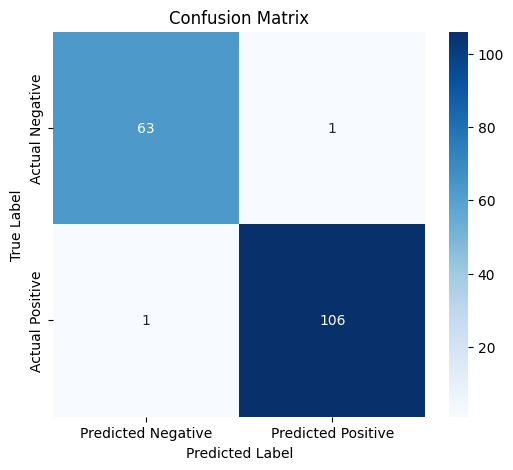

In [15]:
# --- Visualizations ---

# Plot confusion matrix heatmap
cm = np.array([[tn, fp],
               [fn, tp]])
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=['Predicted Negative', 'Predicted Positive'],
            yticklabels=['Actual Negative', 'Actual Positive'])
plt.title("Confusion Matrix")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.show()


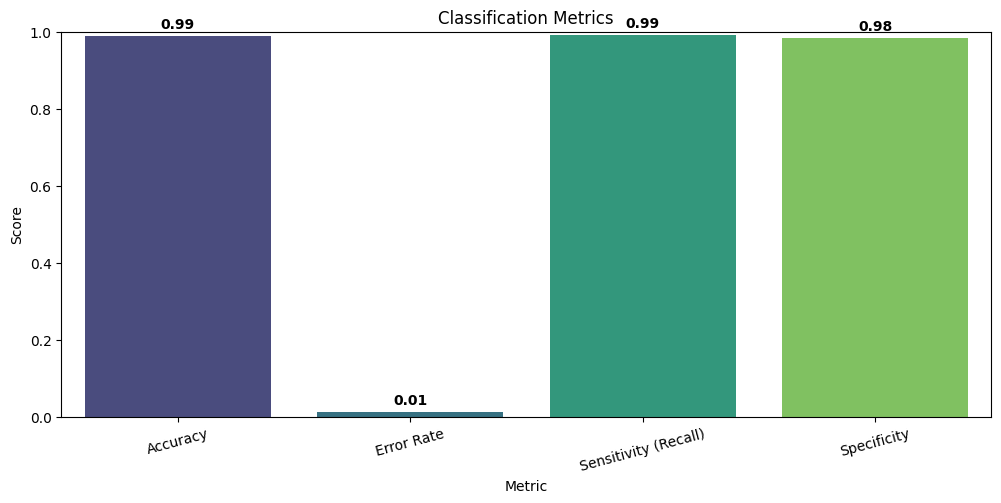

In [16]:
# Prepare a DataFrame for the metrics barplot
metrics = {
    'Accuracy': accuracy_manual,
    'Error Rate': error_rate_manual,
    'Sensitivity (Recall)': sensitivity_manual,
    'Specificity': specificity_manual
}
metrics_df = pd.DataFrame({
    'Metric': list(metrics.keys()),
    'Score': list(metrics.values())
})

# Corrected barplot
plt.figure(figsize=(12, 5))
sns.barplot(data=metrics_df, x='Metric', y='Score', hue='Metric', dodge=False, legend=False, palette="viridis")
plt.ylim(0, 1)
plt.title("Classification Metrics")
plt.ylabel("Score")
plt.xticks(rotation=15)
for i, v in enumerate(metrics_df['Score']):
    plt.text(i, v + 0.02, f"{v:.2f}", ha='center', fontweight='bold')
plt.show()

---

#### **In-Class Reflection: Exercise Summary**

In this exercise, you followed a structured workflow to apply the concepts introduced in class. Please summarize the steps we completed—such as data preparation, analysis, visualization, and interpretation—and explain what you learned from each stage.  

Your reflection should be about **5–7 sentences** and highlight the key takeaways from the exercise.  

> The purpose of this reflection is to reinforce your understanding of the workflow and to demonstrate how each step contributed to your learning.  

---

This exercise focused on understanding classification metrics by calculating them both manually and using built-in functions. The dataset was first loaded and split into training and testing sets, followed by scaling to prepare the data properly. A logistic regression model was trained, and predictions were made on the test data to generate a confusion matrix. From this confusion matrix, key values like true positives, false positives, true negatives, and false negatives were used to manually calculate accuracy, error rate, sensitivity, and specificity. The same metrics were then computed using sklearn functions to verify the manual calculations, and both results matched perfectly. Visualizations like the confusion matrix heatmap and bar plot made it easier to understand how the model performed across different metrics. Overall, the exercise showed how each metric provides a different perspective and why choosing the right one depends on the problem, especially when the cost of errors is different.

#### **Exercise 6: Precision, Recall, and F1-Score — Manual vs. sklearn Calculation**

**Objective:**  
Calculate **precision**, **recall**, and **F1-score** both **manually** and using sklearn’s built-in functions. Compare the results to verify your understanding of how these metrics are derived from the confusion matrix.

**Instructions:**

1. **Load a binary classification dataset** (e.g., Breast Cancer dataset).

2. **Split the data** into training and testing sets.

3. **Train a classifier** (e.g., logistic regression).

4. **Predict on the test set** and generate the **confusion matrix**.

5. **Manually calculate**:
   - Precision = TP / (TP + FP)  
   - Recall (Sensitivity) = TP / (TP + FN)  
   - F1-score = 2 × (Precision × Recall) / (Precision + Recall)  

6. **Use sklearn functions** (`precision_score`, `recall_score`, `f1_score`) to compute the same metrics.

7. **Compare** the manual and sklearn results to ensure they match.

8. **Plot a Precision-Recall curve** to visualize the trade-off between precision and recall.

9. **Discuss** scenarios where higher precision is more important than recall, and vice versa.

---


In [17]:
# Exercise 6: Precision, Recall, and F1-Score — Manual vs. sklearn Calculation

# Imports
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix, precision_score, recall_score, f1_score,
    precision_recall_curve, average_precision_score
)
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1) Load dataset
data = load_breast_cancer()
X = data.data
y = data.target  # In this dataset, class 1 = benign, class 0 = malignant

# 2) Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

# 3) Scale features (helps convergence & stability)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# 4) Train classifier
clf = LogisticRegression(max_iter=1000, solver="lbfgs")
clf.fit(X_train_scaled, y_train)

# 5) Predict class labels AND get scores for PR curve
y_pred = clf.predict(X_test_scaled)
# Prefer decision_function if available; fallback to predict_proba
if hasattr(clf, "decision_function"):
    scores = clf.decision_function(X_test_scaled)
else:
    scores = clf.predict_proba(X_test_scaled)[:, 1]


In [18]:
# 6) Confusion matrix
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
print(f"Confusion Matrix: TP={tp}, FP={fp}, TN={tn}, FN={fn}")


Confusion Matrix: TP=106, FP=1, TN=63, FN=1


In [19]:
# 7) Manual metric calculations
precision_manual = tp / (tp + fp) if (tp + fp) > 0 else 0.0
recall_manual    = tp / (tp + fn) if (tp + fn) > 0 else 0.0
if (precision_manual + recall_manual) > 0:
    f1_manual = 2 * (precision_manual * recall_manual) / (precision_manual + recall_manual)
else:
    f1_manual = 0.0

print("\nManual Metrics:")
print(f"Precision (manual): {precision_manual:.4f}")
print(f"Recall (manual):    {recall_manual:.4f}")
print(f"F1-score (manual):  {f1_manual:.4f}")



Manual Metrics:
Precision (manual): 0.9907
Recall (manual):    0.9907
F1-score (manual):  0.9907


In [20]:
# 8) sklearn metric calculations (positive class defaults to 1)
precision_sk = precision_score(y_test, y_pred, zero_division=0)
recall_sk    = recall_score(y_test, y_pred, zero_division=0)
f1_sk        = f1_score(y_test, y_pred, zero_division=0)

print("\nsklearn Metrics:")
print(f"Precision (sklearn): {precision_sk:.4f}")
print(f"Recall (sklearn):    {recall_sk:.4f}")
print(f"F1-score (sklearn):  {f1_sk:.4f}")

# 9) Validate manual vs sklearn
assert abs(precision_manual - precision_sk) < 1e-9, "Precision mismatch!"
assert abs(recall_manual    - recall_sk)    < 1e-9, "Recall mismatch!"
assert abs(f1_manual        - f1_sk)        < 1e-9, "F1 mismatch!"
print("\nManual and sklearn calculations match.")


sklearn Metrics:
Precision (sklearn): 0.9907
Recall (sklearn):    0.9907
F1-score (sklearn):  0.9907

Manual and sklearn calculations match.


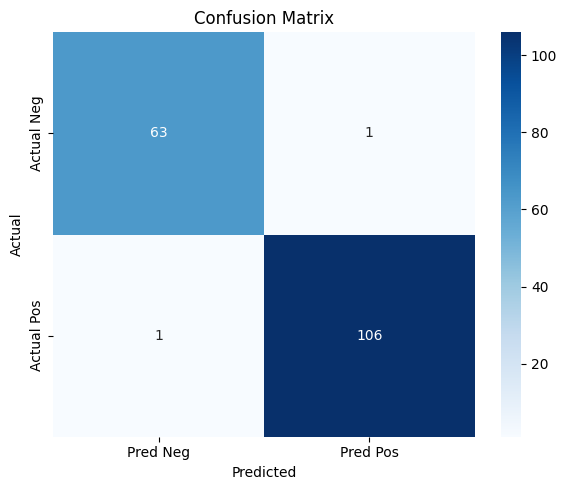

In [21]:
# --- Visualizations ---

# A) Confusion Matrix Heatmap
cm = np.array([[tn, fp],
               [fn, tp]])
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=['Pred Neg', 'Pred Pos'],
            yticklabels=['Actual Neg', 'Actual Pos'])
plt.title("Confusion Matrix")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.show()


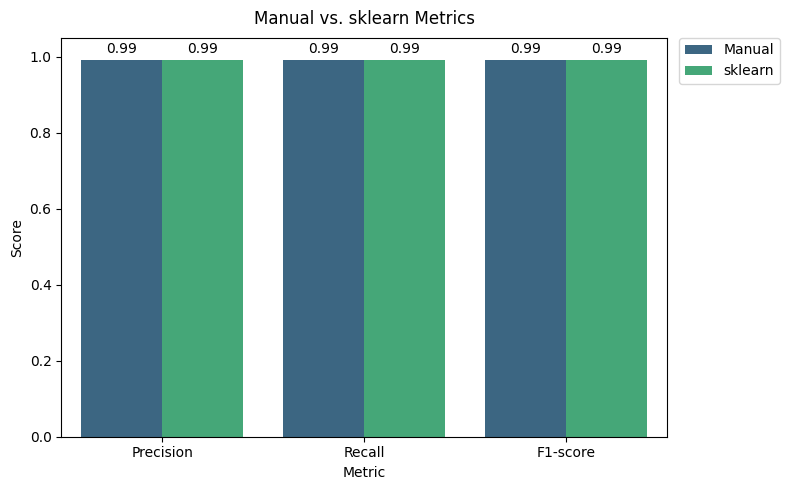

In [22]:
# B) Bar plot comparing manual metrics

metrics_df = pd.DataFrame({
    'Metric': ['Precision', 'Recall', 'F1-score'],
    'Manual': [precision_manual, recall_manual, f1_manual],
    'sklearn': [precision_sk, recall_sk, f1_sk]
})
metrics_df_melt = metrics_df.melt(
    id_vars='Metric', value_vars=['Manual', 'sklearn'],
    var_name='Source', value_name='Score'
)

plt.figure(figsize=(8, 5))
ax = sns.barplot(data=metrics_df_melt, x='Metric', y='Score',
                 hue='Source', palette='viridis')

ax.set_ylim(0, 1.05)                      # little headroom for labels
ax.set_title("Manual vs. sklearn Metrics", pad=10)
ax.set_ylabel("Score")

# Put legend outside so it doesn't collide with labels
ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1), borderaxespad=0)

# Add value labels to each bar (matplotlib >= 3.4)
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=3)

plt.tight_layout()
plt.show()


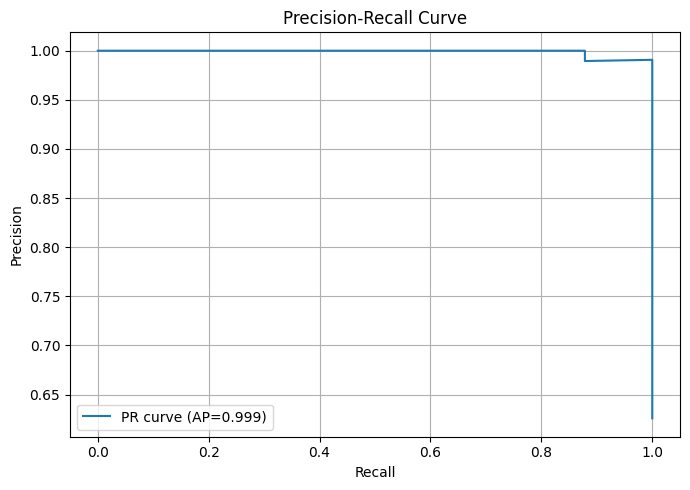

In [23]:
# C) Precision-Recall Curve
precisions, recalls, thresholds = precision_recall_curve(y_test, scores)
avg_prec = average_precision_score(y_test, scores)

plt.figure(figsize=(7, 5))
plt.plot(recalls, precisions, label=f'PR curve (AP={avg_prec:.3f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

---

#### **In-Class Reflection: Exercise Summary**

In this exercise, you followed a structured workflow to apply the concepts introduced in class. Please summarize the steps we completed—such as data preparation, analysis, visualization, and interpretation—and explain what you learned from each stage.  

Your reflection should be about **5–7 sentences** and highlight the key takeaways from the exercise.  

> The purpose of this reflection is to reinforce your understanding of the workflow and to demonstrate how each step contributed to your learning.  

---

This exercise focused on understanding precision, recall, and F1-score by calculating them both manually and using sklearn. The dataset was first loaded and split into training and testing sets, followed by feature scaling to improve model performance. A logistic regression model was trained, and predictions were generated to build the confusion matrix. Using the values from the confusion matrix, precision, recall, and F1-score were calculated manually to understand how each metric is derived. The same metrics were then computed using sklearn, and both results matched exactly, confirming the correctness of the manual calculations. A precision-recall curve was also plotted to show the trade-off between precision and recall at different thresholds. Overall, the exercise showed how these metrics help evaluate model performance more deeply and how different situations may require prioritizing either precision or recall depending on the problem.

#### **Exercise 7: Using Confusion Matrix and Classification Reports**

**Objective:**  
Learn how to generate and interpret **confusion matrices** and **classification reports** for **multi-class classification problems**. You will compare the results visually and numerically to gain a better understanding of classifier performance.

#### **Instructions:**

1. **Load Dataset**  
   Use the **Iris dataset** from `sklearn.datasets` for a multi-class classification task.

2. **Split Data**  
   Divide the dataset into **training** and **testing** sets.

3. **Train Model**  
   Use **Logistic Regression** to train on the training set.

4. **Make Predictions**  
   Predict on the test set.

5. **Generate a Confusion Matrix**  
   - Use `confusion_matrix` from `sklearn.metrics`.
   - Visualize the confusion matrix using `seaborn.heatmap` for clarity.

6. **Create a Classification Report**  
   - Use `classification_report` from `sklearn.metrics` to display **precision**, **recall**, **F1-score**, and **support** for each class.

7. **Interpret the Results**  
   - Explain what the confusion matrix shows for each class.
   - Discuss how precision, recall, and F1-score relate to the confusion matrix values.

#### **Hints:**
- Use `sns.heatmap(cm, annot=True, cmap='Blues', fmt='g')` to create a readable matrix plot.
- Compare the diagonal values to see how many predictions were correct for each class.

---

In [24]:
# Exercise 7: Using Confusion Matrix and Classification Reports

# Imports
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 1) Load Dataset
iris = load_iris()
X = iris.data
y = iris.target
class_names = iris.target_names

# 2) Split Data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

# 3) Train Model (with scaling to aid convergence)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

clf = LogisticRegression(max_iter=1000, multi_class="auto", solver="lbfgs")
clf.fit(X_train_scaled, y_train)

# 4) Make Predictions
y_pred = clf.predict(X_test_scaled)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


In [25]:
# 5) Confusion Matrix (counts)
cm = confusion_matrix(y_test, y_pred)

# Optional: normalized confusion matrix (per true class)
cm_norm = confusion_matrix(y_test, y_pred, normalize="true")

# Print numeric confusion matrix
print("Confusion Matrix (counts):")
print(pd.DataFrame(cm, index=class_names, columns=class_names))


Confusion Matrix (counts):
            setosa  versicolor  virginica
setosa          15           0          0
versicolor       0          14          1
virginica        0           3         12


In [26]:
# 6) Classification Report
report = classification_report(y_test, y_pred, target_names=class_names)
print("\nClassification Report:")
print(report)



Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.82      0.93      0.88        15
   virginica       0.92      0.80      0.86        15

    accuracy                           0.91        45
   macro avg       0.92      0.91      0.91        45
weighted avg       0.92      0.91      0.91        45



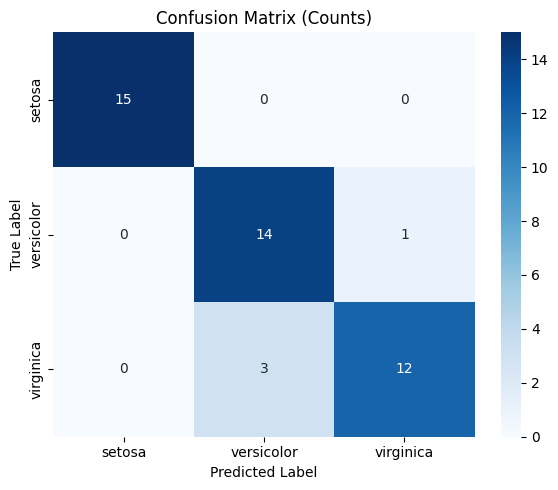

In [27]:
# 5b) Visualize Confusion Matrix (counts)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.title("Confusion Matrix (Counts)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()


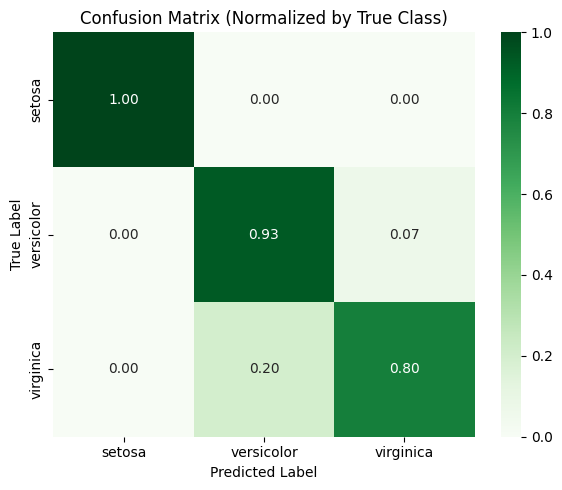

In [28]:
# 5c) Visualize Normalized Confusion Matrix (optional but helpful)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Greens",
            xticklabels=class_names, yticklabels=class_names, vmin=0, vmax=1)
plt.title("Confusion Matrix (Normalized by True Class)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

---

#### **In-Class Reflection: Exercise Summary**

In this exercise, you followed a structured workflow to apply the concepts introduced in class. Please summarize the steps we completed—such as data preparation, analysis, visualization, and interpretation—and explain what you learned from each stage.  

Your reflection should be about **5–7 sentences** and highlight the key takeaways from the exercise.  

> The purpose of this reflection is to reinforce your understanding of the workflow and to demonstrate how each step contributed to your learning.  

---

This exercise focused on understanding how confusion matrices and classification reports help evaluate multi-class classification models. The Iris dataset was first loaded and split into training and testing sets to prepare the data for model building. A logistic regression model was trained after applying feature scaling to improve performance and stability. Predictions were then made on the test set, and a confusion matrix was generated to show how many samples were correctly and incorrectly classified for each class. A classification report was used to summarize precision, recall, and F1-score for each class, giving a more detailed view of performance beyond just accuracy. The heatmaps made it easier to visually interpret where the model performed well and where it made mistakes. Overall, the exercise showed how combining numerical metrics with visual tools provides a clearer understanding of model performance across different classes.

#### **Exercise 8: Customizing Evaluation with Fβ Score**

**Objective:**  
Understand and apply the **Fβ score** to weight **recall vs. precision** according to task needs. You will compute Fβ for multiple β values **manually and with sklearn**, observe how changing β alters the metric, and see how **decision thresholds** affect precision/recall trade-offs.

---

#### **Instructions:**

1. **Load Dataset**  
   Use a **binary classification** dataset (e.g., Breast Cancer from `sklearn.datasets`).

2. **Split Data**  
   Divide the dataset into **training** and **testing** sets.

3. **Train Model**  
   Fit a **Logistic Regression** classifier (scale features to aid convergence).

4. **Get Scores and Predictions**  
   - Obtain **continuous scores** (`decision_function` or `predict_proba` for the positive class).  
   - Generate **class predictions** at the default threshold (0.5).

5. **Compute Fβ Manually (default threshold)**  
   - From the confusion matrix, compute **precision** and **recall**.  
   - For **β ∈ {0.5, 1.0, 2.0}**, compute  

     $
     F_\beta = (1+\beta^2)\cdot\frac{\text{Precision}\cdot\text{Recall}}{(\beta^2\cdot\text{Precision})+\text{Recall}}
     $
     
   - Record the three Fβ scores.

6. **Compute Fβ with sklearn (default threshold)**  
   - Use `fbeta_score` for the same β values and **confirm** results match your manual calculations.

7. **Threshold Analysis**  
   - Sweep **thresholds** from 0.0 to 1.0 (e.g., 101 steps).  
   - For each threshold, compute precision, recall, and Fβ for the chosen β values.  
   - **Find the threshold** that maximizes Fβ for β = 0.5, 1.0, and 2.0 (report three thresholds and scores).

8. **Visualize**  
   - Plot **Fβ vs. threshold** for each β on the same figure.  
   - Optionally, also plot the **Precision–Recall curve** and annotate the best‑Fβ point(s).

9. **Interpretation**  
   - Explain how increasing β emphasizes **recall** over precision.  
   - Discuss which β would be preferable for use cases like **medical screening** (favor recall) vs. **spam filtering** (often favor precision).

#### **Hints:**
- Use `precision_recall_curve` to assist with sweeping thresholds.  
- When computing Fβ manually across thresholds, handle division by zero (set Fβ = 0 if precision + recall = 0).  
- Use `average='binary'` in `fbeta_score` and ensure the **positive class** is correct.

---


In [29]:
# Exercise 8: Customizing Evaluation with Fβ Score

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import gridspec
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix, precision_score, recall_score, fbeta_score,
    precision_recall_curve, average_precision_score
)

# 1) Load dataset (binary)
data = load_breast_cancer()
X = data.data
y = data.target  # positive class = 1

# 2) Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

# 3) Scale features & train LR
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

clf = LogisticRegression(max_iter=1000, solver="lbfgs")
clf.fit(X_train_scaled, y_train)

# 4) Scores & default predictions
proba = clf.predict_proba(X_test_scaled)[:, 1]
y_pred_default = (proba >= 0.5).astype(int)


In [30]:
# 5) Manual Fβ at default threshold
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_default).ravel()
precision_manual = tp / (tp + fp) if (tp + fp) > 0 else 0.0
recall_manual    = tp / (tp + fn) if (tp + fn) > 0 else 0.0

def fbeta_manual(prec, rec, beta):
    if (prec + rec) == 0:
        return 0.0
    b2 = beta**2
    return (1 + b2) * (prec * rec) / (b2 * prec + rec)

betas = [0.5, 1.0, 2.0]
fb_manual = {b: fbeta_manual(precision_manual, recall_manual, b) for b in betas}

print("=== Default threshold (0.5) — Manual ===")
print(f"Precision: {precision_manual:.4f} | Recall: {recall_manual:.4f}")
for b in betas:
    print(f"F{b:g} (manual): {fb_manual[b]:.4f}")


=== Default threshold (0.5) — Manual ===
Precision: 0.9907 | Recall: 0.9907
F0.5 (manual): 0.9907
F1 (manual): 0.9907
F2 (manual): 0.9907


In [31]:
# 6) sklearn Fβ at default threshold
precision_sk = precision_score(y_test, y_pred_default, zero_division=0)
recall_sk    = recall_score(y_test, y_pred_default, zero_division=0)
fb_sklearn   = {b: fbeta_score(y_test, y_pred_default, beta=b, zero_division=0) for b in betas}

print("\n=== Default threshold (0.5) — sklearn ===")
print(f"Precision: {precision_sk:.4f} | Recall: {recall_sk:.4f}")
for b in betas:
    print(f"F{b:g} (sklearn): {fb_sklearn[b]:.4f}")



=== Default threshold (0.5) — sklearn ===
Precision: 0.9907 | Recall: 0.9907
F0.5 (sklearn): 0.9907
F1 (sklearn): 0.9907
F2 (sklearn): 0.9907


In [32]:
# 7) Threshold sweep for best Fβ
thresholds = np.linspace(0.0, 1.0, 101)

def prec_rec_at_thresh(y_true, y_prob, thr):
    yp = (y_prob >= thr).astype(int)
    p = precision_score(y_true, yp, zero_division=0)
    r = recall_score(y_true, yp, zero_division=0)
    return p, r

fb_curves = {b: [] for b in betas}
best = {b: {"thr": None, "fb": -1.0} for b in betas}

for t in thresholds:
    p_t, r_t = prec_rec_at_thresh(y_test, proba, t)
    for b in betas:
        fb_t = fbeta_manual(p_t, r_t, b)
        fb_curves[b].append(fb_t)
        if fb_t > best[b]["fb"]:
            best[b]["fb"] = fb_t
            best[b]["thr"] = t

print("\n=== Best thresholds by Fβ ===")
for b in betas:
    print(f"Best F{b:g}: {best[b]['fb']:.4f} at threshold = {best[b]['thr']:.2f}")



=== Best thresholds by Fβ ===
Best F0.5: 0.9926 at threshold = 0.37
Best F1: 0.9953 at threshold = 0.37
Best F2: 0.9981 at threshold = 0.37


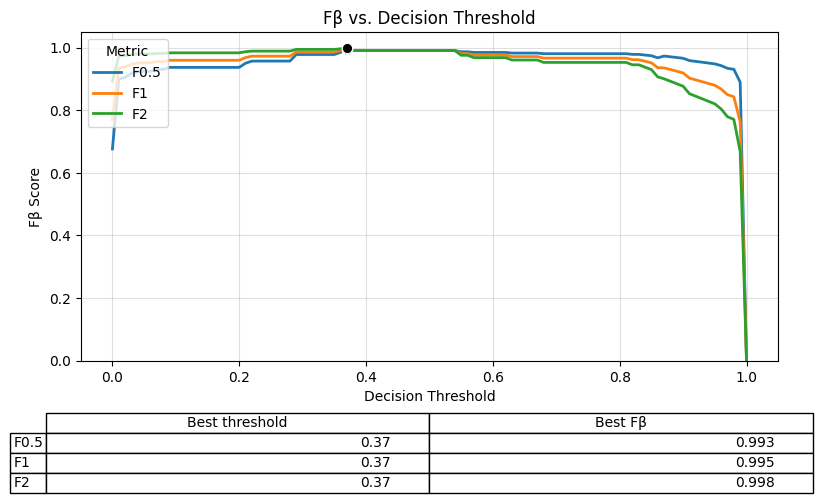

In [33]:
# 8A) Fβ vs Threshold (clean: markers + summary table, no on-plot text)
fig = plt.figure(figsize=(9, 6))
gs = gridspec.GridSpec(2, 1, height_ratios=[4, 1], hspace=0.25)

ax = fig.add_subplot(gs[0])
colors = {0.5: 'C0', 1.0: 'C1', 2.0: 'C2'}
labels = {0.5: 'F0.5', 1.0: 'F1', 2.0: 'F2'}

# Plot curves
for b in betas:
    ax.plot(thresholds, fb_curves[b], label=labels[b], color=colors[b], lw=2)

# Mark best points (no text)
for b in betas:
    x, yb = best[b]["thr"], best[b]["fb"]
    ax.scatter(x, yb, s=55, color='black', zorder=3, edgecolor='white', linewidth=0.8)

ax.set_xlabel("Decision Threshold")
ax.set_ylabel("Fβ Score")
ax.set_title("Fβ vs. Decision Threshold")
ax.set_ylim(0, 1.05)
ax.grid(True, alpha=0.4)
ax.legend(title="Metric", loc='upper left')

# Summary table below the plot
table_ax = fig.add_subplot(gs[1])
table_ax.axis("off")
row_labels = [labels[b] for b in betas]
cell_text  = [[f"{best[b]['thr']:.2f}", f"{best[b]['fb']:.3f}"] for b in betas]
table = table_ax.table(
    cellText=cell_text,
    rowLabels=row_labels,
    colLabels=["Best threshold", "Best Fβ"],
    loc="center"
)
table.scale(1.1, 1.2)

plt.show()


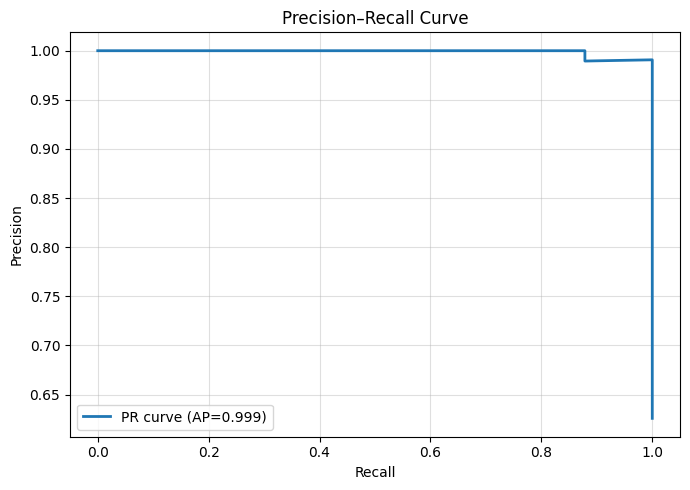

In [34]:
# 8B) Precision–Recall curve (with AP)
precisions, recalls, pr_thresholds = precision_recall_curve(y_test, proba)
ap = average_precision_score(y_test, proba)

plt.figure(figsize=(7, 5))
plt.plot(recalls, precisions, label=f'PR curve (AP={ap:.3f})', lw=2)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve")
plt.grid(True, alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()


---

#### **In-Class Reflection: Exercise Summary**

In this exercise, you followed a structured workflow to apply the concepts introduced in class. Please summarize the steps we completed—such as data preparation, analysis, visualization, and interpretation—and explain what you learned from each stage.  

Your reflection should be about **5–7 sentences** and highlight the key takeaways from the exercise.  

> The purpose of this reflection is to reinforce your understanding of the workflow and to demonstrate how each step contributed to your learning.  

---

This exercise focused on understanding how the Fβ score can be used to balance precision and recall based on different priorities. The dataset was first loaded and split into training and testing sets, followed by scaling and training a logistic regression model. Predictions were generated using probabilities, which allowed evaluation at different thresholds instead of just the default 0.5. Precision, recall, and Fβ scores were first calculated manually using values from the confusion matrix and then verified using sklearn, and both results matched. The model was then evaluated across many thresholds to see how Fβ changes and to find the best threshold for different β values. Visualizations helped show how increasing β places more importance on recall compared to precision. Overall, the exercise showed how threshold tuning and Fβ scores can be used to adapt model evaluation to different real-world needs, such as prioritizing safety in medical cases or reducing false positives in filtering tasks.

#### **Module 8.3: Precision, Recall, and F-Score**

Precision and recall are fundamental metrics used to evaluate classification models, especially in cases with class imbalance or when the costs of different errors vary.

- **Precision** measures the proportion of positive identifications that were actually correct:  


  $
  \text{Precision} = \frac{TP}{TP + FP}
  $


  High precision means few false positives.

- **Recall (Sensitivity)** measures the proportion of actual positives that were correctly identified:  


  $
  \text{Recall} = \frac{TP}{TP + FN}
  $

  
  High recall means few false negatives.

- **F-Score (F₁ Score)** is the harmonic mean of precision and recall, providing a balanced measure:  


  $
  F_1 = 2 \times \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}
  $

- **Fβ Score** generalizes F₁ by weighting recall more than precision (if β > 1) or vice versa (if β < 1):  


  $
  F_\beta = (1 + \beta^2) \times \frac{\text{Precision} \times \text{Recall}}{\beta^2 \times \text{Precision} + \text{Recall}}
  $

These metrics help you choose models that align with the specific priorities of your application, such as minimizing false positives or false negatives.

---

#### **Exercise 9: Calculating Precision, Recall, and F₁ Score from a Confusion Matrix**

In this exercise, we’ll work with the **Breast Cancer dataset** from `sklearn.datasets` to understand how to calculate **precision**, **recall**, and **F₁ score** directly from a confusion matrix. These metrics are essential when evaluating classification models, especially when the costs of false positives and false negatives differ.

You will:
- Load and split the dataset into training and testing sets.
- Train a Logistic Regression model.
- Generate predictions and build a confusion matrix.
- Calculate precision, recall, and F₁ score manually using the confusion matrix values.
- Compare your manual calculations with results from `precision_score()`, `recall_score()`, and `f1_score()` in `sklearn.metrics`.

By the end of this exercise, you will clearly see how these metrics are derived and how they help in understanding model performance beyond just accuracy.

---

In [35]:
# Exercise 9: Calculating Precision, Recall, and F1 Score from a Confusion Matrix
# ------------------------------------------------------------
# Objective:
# Compute precision, recall, and F1 score manually from a confusion matrix
# for a binary classification problem, and compare with scikit-learn metrics.

# Step 1: Imports
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score

# Step 2: Load dataset
data = load_breast_cancer()
X, y = data.data, data.target  # y: 0=malignant, 1=benign

# Step 3: Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

# Step 4: Train model (Logistic Regression)
clf = LogisticRegression(max_iter=500, solver="liblinear", random_state=42)
clf.fit(X_train, y_train)

# Step 5: Predictions
y_pred = clf.predict(X_test)


In [36]:
# Step 6: Confusion matrix (labels ensure correct ordering: 0=negative, 1=positive)
cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
TN, FP, FN, TP = cm.ravel()

print("Confusion Matrix (rows=true, cols=pred):\n", cm)
print(f"\nTN={TN}, FP={FP}, FN={FN}, TP={TP}")


Confusion Matrix (rows=true, cols=pred):
 [[48  5]
 [ 1 89]]

TN=48, FP=5, FN=1, TP=89


In [37]:
# Step 7: Manual calculations
precision_manual = TP / (TP + FP) if (TP + FP) > 0 else 0.0
recall_manual = TP / (TP + FN) if (TP + FN) > 0 else 0.0
f1_manual = (
    2 * (precision_manual * recall_manual) / (precision_manual + recall_manual)
    if (precision_manual + recall_manual) > 0
    else 0.0
)

print("\nManual Metrics:")
print(f"Precision (manual): {precision_manual:.4f}")
print(f"Recall    (manual): {recall_manual:.4f}")
print(f"F1 score  (manual): {f1_manual:.4f}")

# Step 8: Compare with scikit-learn
precision_lib = precision_score(y_test, y_pred, pos_label=1, zero_division=0)
recall_lib = recall_score(y_test, y_pred, pos_label=1, zero_division=0)
f1_lib = f1_score(y_test, y_pred, pos_label=1, zero_division=0)

print("\nscikit-learn Metrics:")
print(f"Precision (sklearn): {precision_lib:.4f}")
print(f"Recall    (sklearn): {recall_lib:.4f}")
print(f"F1 score  (sklearn): {f1_lib:.4f}")

# Quick check
assert np.isclose(precision_manual, precision_lib), "Precision mismatch!"
assert np.isclose(recall_manual, recall_lib), "Recall mismatch!"
assert np.isclose(f1_manual, f1_lib), "F1 mismatch!"

print("\nAll manual metrics match scikit-learn outputs!")


Manual Metrics:
Precision (manual): 0.9468
Recall    (manual): 0.9889
F1 score  (manual): 0.9674

scikit-learn Metrics:
Precision (sklearn): 0.9468
Recall    (sklearn): 0.9889
F1 score  (sklearn): 0.9674

All manual metrics match scikit-learn outputs!


---

#### **In-Class Reflection: Exercise Summary**

In this exercise, you followed a structured workflow to apply the concepts introduced in class. Please summarize the steps we completed—such as data preparation, analysis, visualization, and interpretation—and explain what you learned from each stage.  

Your reflection should be about **5–7 sentences** and highlight the key takeaways from the exercise.  

> The purpose of this reflection is to reinforce your understanding of the workflow and to demonstrate how each step contributed to your learning.  

---

This exercise focused on understanding how precision, recall, and F1-score are derived from a confusion matrix and how they relate to model performance. The Breast Cancer dataset was first loaded and split into training and testing sets to prepare the data for modeling. A logistic regression model was trained, and predictions were generated on the test set. The confusion matrix was then used to identify true positives, false positives, true negatives, and false negatives, which were used to manually calculate precision, recall, and F1-score. These manually computed values were then compared with sklearn’s built-in functions, and both results matched exactly, confirming correctness. The exercise helped connect formulas to real values in the confusion matrix and made it clear how each metric reflects different types of prediction errors. Overall, it showed how these metrics provide deeper insight into model performance beyond simple accuracy.

#### **Exercise 10: Comparing Classifiers with Classification Reports**

In this exercise, we’ll use the **Wine dataset** from `sklearn.datasets` to compare multiple classifiers using the `classification_report()` function. This tool gives a detailed breakdown of **precision**, **recall**, and **F₁ scores** for each class, along with macro and weighted averages.

You will:
- Load and split the dataset into training and testing sets.
- Train at least two different classifiers.
- Generate predictions for each model.
- Use `classification_report()` to evaluate precision, recall, and F₁ score for each class.
- Compare the strengths and weaknesses of the models based on these metrics.

By the end of this exercise, you will be able to quickly compare classifiers and decide which model best meets the goals of your application.

---

In [38]:
# Exercise 10: Comparing Classifiers with Classification Reports
# --------------------------------------------------------------

# Step 1: Imports
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# Step 2: Load dataset
data = load_wine()
X, y = data.data, data.target

# Step 3: Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Step 4: Scale features for Logistic Regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [39]:
# Step 5: Train classifiers
clf1 = LogisticRegression(max_iter=1000, solver="lbfgs", multi_class="auto", random_state=42)
clf2 = RandomForestClassifier(n_estimators=200, random_state=42)

clf1.fit(X_train_scaled, y_train)  # scaled data
clf2.fit(X_train, y_train)         # tree models don't need scaling


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


RandomForestClassifier(n_estimators=200, random_state=42)

In [40]:
# Step 6: Predictions
y_pred1 = clf1.predict(X_test_scaled)
y_pred2 = clf2.predict(X_test)

# Step 7: Classification reports
print("Logistic Regression Report:\n")
print(classification_report(y_test, y_pred1, target_names=data.target_names))

print("\nRandom Forest Report:\n")
print(classification_report(y_test, y_pred2, target_names=data.target_names))

Logistic Regression Report:

              precision    recall  f1-score   support

     class_0       0.95      1.00      0.97        18
     class_1       1.00      0.95      0.98        21
     class_2       1.00      1.00      1.00        15

    accuracy                           0.98        54
   macro avg       0.98      0.98      0.98        54
weighted avg       0.98      0.98      0.98        54


Random Forest Report:

              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        18
     class_1       1.00      1.00      1.00        21
     class_2       1.00      1.00      1.00        15

    accuracy                           1.00        54
   macro avg       1.00      1.00      1.00        54
weighted avg       1.00      1.00      1.00        54



---

#### **In-Class Reflection: Exercise Summary**

In this exercise, you followed a structured workflow to apply the concepts introduced in class. Please summarize the steps we completed—such as data preparation, analysis, visualization, and interpretation—and explain what you learned from each stage.  

Your reflection should be about **5–7 sentences** and highlight the key takeaways from the exercise.  

> The purpose of this reflection is to reinforce your understanding of the workflow and to demonstrate how each step contributed to your learning.  

---

In this exercise, the Wine dataset was first loaded and split into training and testing sets to prepare the data for model building. The features were scaled for Logistic Regression to improve performance, while Random Forest was trained on the original data since it does not require scaling. Two different classifiers were then trained to understand how different models behave on the same dataset. Predictions were generated for both models and evaluated using the classification_report function, which provided precision, recall, and F1-score for each class. The results showed that Logistic Regression performed very well, but Random Forest achieved perfect scores across all metrics. This comparison made it clear how model choice can impact performance and how classification reports help in understanding strengths and weaknesses beyond just accuracy.

#### **Exercise 11: Visualizing the Precision–Recall Trade‑off Curve**

In this exercise, you’ll generate and interpret a **Precision–Recall (PR) curve** to understand how changing the decision threshold affects precision and recall in an imbalanced binary classification problem. We’ll create a synthetic, **class‑imbalanced** dataset using `make_classification`, train a Logistic Regression model, and visualize how precision and recall move in opposite directions as the threshold shifts.

You will:
- Create an imbalanced binary dataset with `make_classification`.
- Split the data and scale features for Logistic Regression.
- Compute `precision_recall_curve` and `average_precision_score`.
- Plot the PR curve and mark a few example thresholds.
- Discuss where you’d operate depending on whether **false positives** or **false negatives** matter more.

---

In [41]:
# Exercise 11: Visualizing the Precision–Recall Trade‑off Curve
# ------------------------------------------------------------

# Step 1: Imports
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_recall_curve, average_precision_score

# Step 2: Create an imbalanced binary dataset
X, y = make_classification(
    n_samples=4000,
    n_features=20,
    n_informative=6,
    n_redundant=4,
    n_repeated=0,
    n_classes=2,
    weights=[0.85, 0.15],   # 15% positive class
    class_sep=1.2,
    random_state=42
)

# Step 3: Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=42
)

# Step 4: Scale features (helps LR converge and behave well)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

# Step 5: Train Logistic Regression
clf = LogisticRegression(max_iter=1000, solver="lbfgs", random_state=42)
clf.fit(X_train_sc, y_train)

# Step 6: Predict probabilities for the positive class
y_score = clf.predict_proba(X_test_sc)[:, 1]


In [42]:
# Step 7: Precision-Recall curve + Average Precision
prec, rec, thresh = precision_recall_curve(y_test, y_score)
ap = average_precision_score(y_test, y_score)

print(f"Average Precision (area under PR curve): {ap:.4f}")


Average Precision (area under PR curve): 0.9175


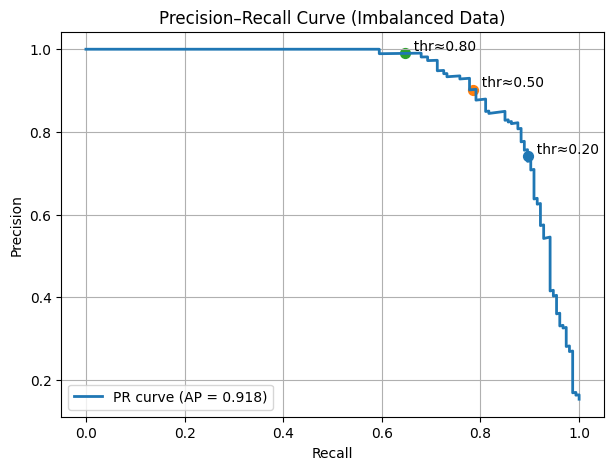

In [43]:
# Step 8: Plot PR curve and annotate a few thresholds
plt.figure(figsize=(7, 5))
plt.plot(rec, prec, linewidth=2, label=f"PR curve (AP = {ap:.3f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve (Imbalanced Data)")
plt.grid(True)
plt.legend(loc="best")

# Mark a few example thresholds near 0.2, 0.5, 0.8 (find closest)
for t_target in [0.2, 0.5, 0.8]:
    # Find index in thresh closest to target (note: thresh has length len(prec)-1)
    idx = np.argmin(np.abs(thresh - t_target))
    plt.scatter(rec[idx], prec[idx], s=50)
    plt.text(rec[idx], prec[idx], f"  thr≈{thresh[idx]:.2f}", va="bottom")

plt.show()

In [44]:
# Optional: Inspect how F1 varies with threshold
eps = 1e-12
f1 = 2 * (prec * rec) / (prec + rec + eps)
best_idx = np.argmax(f1)
print(f"Best F1≈{f1[best_idx]:.4f} at recall={rec[best_idx]:.3f}, precision={prec[best_idx]:.3f}")

Best F1≈0.8497 at recall=0.850, precision=0.850


---

#### **In-Class Reflection: Exercise Summary**

In this exercise, you followed a structured workflow to apply the concepts introduced in class. Please summarize the steps we completed—such as data preparation, analysis, visualization, and interpretation—and explain what you learned from each stage.  

Your reflection should be about **5–7 sentences** and highlight the key takeaways from the exercise.  

> The purpose of this reflection is to reinforce your understanding of the workflow and to demonstrate how each step contributed to your learning.  

---

In this exercise, an imbalanced binary dataset was first created using make_classification to simulate a real-world scenario where one class is much rarer than the other. The data was then split into training and testing sets, and feature scaling was applied to help the Logistic Regression model perform effectively. After training the model, probability scores were generated instead of direct class predictions so that different classification thresholds could be analyzed. A precision–recall curve was then plotted to show how precision and recall change as the decision threshold varies, and the average precision score was used to summarize overall performance. The graph helped visualize the trade-off between precision and recall, especially in an imbalanced dataset where accuracy alone can be misleading. It was also observed how different thresholds impact model behavior, depending on whether false positives or false negatives are more important. Overall, the exercise demonstrated how PR curves provide a clearer understanding of model performance in real-world classification problems.

#### **Exercise 12: Choosing the Optimal Threshold using Fβ Score**

In this exercise, you’ll learn how to select a decision threshold that maximizes the **Fβ score**, which allows you to weight recall more heavily (β > 1) or precision more heavily (β < 1). This is important when the costs of false negatives and false positives are not equal.

You will:
- Create an imbalanced binary dataset with `make_classification`.
- Train a Logistic Regression model and predict probabilities.
- For multiple β values (0.5, 1, 2), compute the Fβ score at various thresholds.
- Find and report the threshold that maximizes the Fβ score for each β.
- Compare how different β values shift the optimal threshold.

---

In [45]:
# Exercise 12: Choosing the Optimal Threshold using Fβ Score
# ----------------------------------------------------------

# Step 1: Imports
import numpy as np
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_score, recall_score, fbeta_score

# Step 2: Create imbalanced dataset
X, y = make_classification(
    n_samples=4000,
    n_features=20,
    n_informative=6,
    n_redundant=4,
    n_classes=2,
    weights=[0.85, 0.15],   # 15% positive class
    class_sep=1.2,
    random_state=42
)

# Step 3: Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=42
)

# Step 4: Scale features
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

# Step 5: Train Logistic Regression
clf = LogisticRegression(max_iter=1000, solver="lbfgs", random_state=42)
clf.fit(X_train_sc, y_train)

# Step 6: Get predicted probabilities
y_prob = clf.predict_proba(X_test_sc)[:, 1]


In [46]:
# Step 7: Evaluate Fβ score for different thresholds and β values
betas = [0.5, 1, 2]
thresholds = np.linspace(0, 1, 101)

for beta in betas:
    best_fbeta = 0
    best_thresh = 0
    for t in thresholds:
        y_pred_thresh = (y_prob >= t).astype(int)
        fbeta = fbeta_score(y_test, y_pred_thresh, beta=beta, zero_division=0)
        if fbeta > best_fbeta:
            best_fbeta = fbeta
            best_thresh = t
    print(f"Best F{beta} Score: {best_fbeta:.4f} at Threshold: {best_thresh:.2f}")


Best F0.5 Score: 0.9075 at Threshold: 0.74
Best F1 Score: 0.8481 at Threshold: 0.32
Best F2 Score: 0.8654 at Threshold: 0.28


In [47]:
# Step 8: Example — Precision and Recall at optimal threshold for β=2
opt_beta = 2
opt_thresh = max(
    thresholds,
    key=lambda t: fbeta_score(y_test, (y_prob >= t).astype(int), beta=opt_beta, zero_division=0)
)
y_pred_opt = (y_prob >= opt_thresh).astype(int)
prec = precision_score(y_test, y_pred_opt, zero_division=0)
rec = recall_score(y_test, y_pred_opt, zero_division=0)

print(f"\nFor β={opt_beta}, optimal threshold={opt_thresh:.2f}")
print(f"Precision={prec:.4f}, Recall={rec:.4f}")


For β=2, optimal threshold=0.28
Precision=0.8036, Recall=0.8824


---

#### **In-Class Reflection: Exercise Summary**

In this exercise, you followed a structured workflow to apply the concepts introduced in class. Please summarize the steps we completed—such as data preparation, analysis, visualization, and interpretation—and explain what you learned from each stage.  

Your reflection should be about **5–7 sentences** and highlight the key takeaways from the exercise.  

> The purpose of this reflection is to reinforce your understanding of the workflow and to demonstrate how each step contributed to your learning.  

---

In this exercise, an imbalanced binary dataset was first created using make_classification to reflect real-world situations where one class is less frequent than the other. The data was then split into training and testing sets, and feature scaling was applied to ensure the Logistic Regression model performed well. After training the model, probability scores were generated so that different classification thresholds could be tested instead of relying on a fixed default value. The Fβ score was then calculated across multiple thresholds for different β values (0.5, 1, and 2) to understand how the balance between precision and recall changes. It was observed that smaller β values favored higher precision with higher thresholds, while larger β values favored higher recall with lower thresholds. This showed how adjusting β directly influences the choice of optimal threshold depending on the problem requirements. Overall, the exercise demonstrated how Fβ scoring can be used to make more practical and goal-driven decisions in classification tasks.

#### **Module 8.4: Cross-Validation and Model Evaluation Methods**

Cross-validation is a technique used to assess how a model will generalize to an independent dataset by systematically splitting the data into training and testing subsets multiple times.

Key methods include:  
- **k-Fold Cross-Validation:** The dataset is divided into k equal parts (folds). The model is trained on k-1 folds and tested on the remaining fold. This process repeats k times, with each fold used once as the test set. The results are averaged to estimate model performance.  
- **Hold-Out Validation:** A simple approach where the data is split once into training and testing sets. It is faster but may provide less reliable performance estimates.  
- **Stratified Sampling:** Ensures that class proportions are preserved in each fold or split, especially important for imbalanced classification tasks.  
- **Repeated Cross-Validation:** Combines k-fold with multiple repetitions to further reduce variance in estimates.

Cross-validation provides a robust and unbiased way to evaluate models and compare their performance fairly.

---

#### **Exercise 13: Implementing Hold-Out Validation**

In this exercise, you will practice the **hold-out validation** technique, one of the simplest methods for evaluating model performance. The dataset will be split into a single training set and a testing set. You’ll train a model on the training data, evaluate it on the testing data, and interpret the results.

You will:
- Load a dataset from `sklearn.datasets`.
- Split the data into training and testing sets using `train_test_split`.
- Train a classification model on the training data.
- Evaluate the model on the test set using accuracy, precision, recall, and F₁ score.
- Understand the benefits and limitations of the hold-out approach.

---

In [48]:
# Exercise 13: Implementing Hold-Out Validation
# ----------------------------------------------

# Step 1: Imports
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Step 2: Load dataset
data = load_breast_cancer()
X, y = data.data, data.target


In [49]:
# Step 3: Hold-out split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [50]:
# Step 4: Train model
clf = LogisticRegression(max_iter=1000, solver="liblinear", random_state=42)
clf.fit(X_train, y_train)

# Step 5: Predictions
y_pred = clf.predict(X_test)

# Step 6: Evaluation metrics
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Hold-Out Validation Results:")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1 Score : {f1:.4f}")

Hold-Out Validation Results:
Accuracy : 0.9561
Precision: 0.9589
Recall   : 0.9722
F1 Score : 0.9655


---

#### **In-Class Reflection: Exercise Summary**

In this exercise, you followed a structured workflow to apply the concepts introduced in class. Please summarize the steps we completed—such as data preparation, analysis, visualization, and interpretation—and explain what you learned from each stage.  

Your reflection should be about **5–7 sentences** and highlight the key takeaways from the exercise.  

> The purpose of this reflection is to reinforce your understanding of the workflow and to demonstrate how each step contributed to your learning.  

---

In this exercise, the Breast Cancer dataset was first loaded and prepared for model building. The data was then split into training and testing sets using the hold-out validation method, which separates the data only once for evaluation. A Logistic Regression model was trained on the training data and then used to make predictions on the test set. The model’s performance was evaluated using accuracy, precision, recall, and F1 score to get a complete understanding of its behavior. The results showed strong performance across all metrics, indicating that the model was able to classify the data effectively. This exercise helped demonstrate how hold-out validation works as a simple and fast evaluation method, while also showing its limitation of relying on a single split. Overall, it reinforced how different metrics together provide a clearer picture of model performance.

#### **Exercise 14: Performing k-Fold Cross-Validation**

In this exercise, you’ll practice **k‑Fold Cross‑Validation** to estimate model performance more reliably than a single train/test split. You’ll use the **Iris dataset** (multi-class) and compare two classifiers across folds, observing mean and variability of scores.

You will:
- Create a `KFold` splitter (k=5) and iterate folds.
- Evaluate models with `cross_val_score` / `cross_validate`.
- Report **accuracy** and **F1‑macro** means and standard deviations.
- Compare two models to see which generalizes better and which is more stable.

---

In [51]:
# Exercise 14: Performing k-Fold Cross-Validation
# -----------------------------------------------

# Step 1: Imports
import numpy as np
from sklearn.datasets import load_iris
from sklearn.model_selection import KFold, cross_val_score, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Step 2: Load dataset
data = load_iris()
X, y = data.data, data.target

In [52]:
# Step 3: Define 5-fold CV splitter (non-stratified on purpose for this exercise)
kf = KFold(n_splits=5, shuffle=True, random_state=42)

In [53]:
# Step 4: Define models
# Use a pipeline to ensure proper scaling for Logistic Regression
log_reg = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=1000, multi_class="auto", solver="lbfgs", random_state=42))
])

rf = RandomForestClassifier(n_estimators=200, random_state=42)


In [54]:
# Step 5: Evaluate with cross_val_score for quick metrics (Accuracy)
acc_lr = cross_val_score(log_reg, X, y, cv=kf, scoring="accuracy")
acc_rf = cross_val_score(rf, X, y, cv=kf, scoring="accuracy")

print("Accuracy (5-fold CV)")
print(f"  LogisticRegression: mean={acc_lr.mean():.4f}, std={acc_lr.std():.4f}, folds={np.round(acc_lr,4)}")
print(f"  RandomForest      : mean={acc_rf.mean():.4f}, std={acc_rf.std():.4f}, folds={np.round(acc_rf,4)}")


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and wi

Accuracy (5-fold CV)
  LogisticRegression: mean=0.9533, std=0.0340, folds=[1.     0.9667 0.9333 0.9    0.9667]
  RandomForest      : mean=0.9600, std=0.0249, folds=[1.     0.9667 0.9333 0.9333 0.9667]


In [55]:
# Step 6: Use cross_validate to collect multiple metrics
scoring = {"acc":"accuracy", "f1_macro":"f1_macro"}
cv_lr = cross_validate(log_reg, X, y, cv=kf, scoring=scoring, return_train_score=True)
cv_rf = cross_validate(rf, X, y, cv=kf, scoring=scoring, return_train_score=True)

def summarize_cv(name, cvres):
    acc_mean, acc_std = cvres["test_acc"].mean(), cvres["test_acc"].std()
    f1_mean, f1_std   = cvres["test_f1_macro"].mean(), cvres["test_f1_macro"].std()
    tr_acc_mean = cvres["train_acc"].mean()
    print(f"\n{name} — 5-fold cross_validate results")
    print(f"  Test Accuracy : mean={acc_mean:.4f}, std={acc_std:.4f}")
    print(f"  Test F1-macro : mean={f1_mean:.4f}, std={f1_std:.4f}")
    print(f"  Train Accuracy: mean={tr_acc_mean:.4f} (useful to spot overfitting)")

summarize_cv("LogisticRegression (with scaling)", cv_lr)
summarize_cv("RandomForest", cv_rf)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and wi


LogisticRegression (with scaling) — 5-fold cross_validate results
  Test Accuracy : mean=0.9533, std=0.0340
  Test F1-macro : mean=0.9529, std=0.0324
  Train Accuracy: mean=0.9683 (useful to spot overfitting)

RandomForest — 5-fold cross_validate results
  Test Accuracy : mean=0.9600, std=0.0249
  Test F1-macro : mean=0.9589, std=0.0258
  Train Accuracy: mean=1.0000 (useful to spot overfitting)


---

#### **In-Class Reflection: Exercise Summary**

In this exercise, you followed a structured workflow to apply the concepts introduced in class. Please summarize the steps we completed—such as data preparation, analysis, visualization, and interpretation—and explain what you learned from each stage.  

Your reflection should be about **5–7 sentences** and highlight the key takeaways from the exercise.  

> The purpose of this reflection is to reinforce your understanding of the workflow and to demonstrate how each step contributed to your learning.  

---

In this exercise, the Iris dataset was first loaded and prepared for model evaluation using cross-validation. A 5-fold KFold split was created so the data could be tested on different subsets, giving a more reliable estimate of performance than a single train-test split. Two models, Logistic Regression and Random Forest, were then evaluated using cross_val_score to compare their accuracy across folds. After that, cross_validate was used to also measure F1-macro and training performance, helping to check both performance and possible overfitting. The results showed that both models performed well, but Random Forest had slightly higher average accuracy and lower variation across folds. It was also observed that Random Forest achieved perfect training accuracy, which may indicate some level of overfitting compared to Logistic Regression. Overall, the exercise demonstrated how k-fold cross-validation provides a more stable and trustworthy way to compare machine learning models.

#### **Exercise 15: Using Stratified k-Fold for Imbalanced Classification**

In this exercise, you will apply **Stratified k-Fold Cross-Validation** to handle class imbalance. Unlike regular k-Fold, the **stratified** version preserves the percentage of samples for each class in every fold. This is especially important for imbalanced classification problems where some classes have far fewer examples.

You will:
- Create an imbalanced binary classification dataset.
- Compare regular `KFold` and `StratifiedKFold` to see the difference in class distribution across folds.
- Evaluate a classifier using stratified k-fold and report mean accuracy and F1-score.

---

In [56]:
# Exercise 15: Using Stratified k-Fold for Imbalanced Classification
# -----------------------------------------------------------------

# Step 1: Imports
import numpy as np
from sklearn.datasets import make_classification
from sklearn.model_selection import KFold, StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from collections import Counter

# Step 2: Create an imbalanced binary dataset
X, y = make_classification(
    n_samples=1000,
    n_features=10,
    n_informative=5,
    n_redundant=2,
    n_classes=2,
    weights=[0.9, 0.1],  # 10% positive class
    random_state=42
)


In [57]:
# Step 3: Compare KFold vs. StratifiedKFold class distribution
print("KFold class distribution per fold:")
kf = KFold(n_splits=5, shuffle=True, random_state=42)
for i, (_, test_idx) in enumerate(kf.split(X, y), start=1):
    print(f" Fold {i}: {Counter(y[test_idx])}")

print("\nStratifiedKFold class distribution per fold:")
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
for i, (_, test_idx) in enumerate(skf.split(X, y), start=1):
    print(f" Fold {i}: {Counter(y[test_idx])}")


KFold class distribution per fold:
 Fold 1: Counter({np.int64(0): 179, np.int64(1): 21})
 Fold 2: Counter({np.int64(0): 182, np.int64(1): 18})
 Fold 3: Counter({np.int64(0): 186, np.int64(1): 14})
 Fold 4: Counter({np.int64(0): 172, np.int64(1): 28})
 Fold 5: Counter({np.int64(0): 177, np.int64(1): 23})

StratifiedKFold class distribution per fold:
 Fold 1: Counter({np.int64(0): 180, np.int64(1): 20})
 Fold 2: Counter({np.int64(0): 179, np.int64(1): 21})
 Fold 3: Counter({np.int64(0): 179, np.int64(1): 21})
 Fold 4: Counter({np.int64(0): 179, np.int64(1): 21})
 Fold 5: Counter({np.int64(0): 179, np.int64(1): 21})


In [58]:
# Step 4: Evaluate model with StratifiedKFold
clf = LogisticRegression(max_iter=1000, solver="liblinear", random_state=42)
acc_scores = cross_val_score(clf, X, y, cv=skf, scoring="accuracy")
f1_scores = cross_val_score(clf, X, y, cv=skf, scoring="f1")

print("\nStratified k-Fold CV Results:")
print(f" Accuracy: mean={acc_scores.mean():.4f}, std={acc_scores.std():.4f}")
print(f" F1-score: mean={f1_scores.mean():.4f}, std={f1_scores.std():.4f}")


Stratified k-Fold CV Results:
 Accuracy: mean=0.9060, std=0.0150
 F1-score: mean=0.3212, std=0.1326


---

#### **In-Class Reflection: Exercise Summary**

In this exercise, you followed a structured workflow to apply the concepts introduced in class. Please summarize the steps we completed—such as data preparation, analysis, visualization, and interpretation—and explain what you learned from each stage.  

Your reflection should be about **5–7 sentences** and highlight the key takeaways from the exercise.  

> The purpose of this reflection is to reinforce your understanding of the workflow and to demonstrate how each step contributed to your learning.  

---

In this exercise, an imbalanced binary dataset was first created to simulate a real-world situation where one class has far fewer samples than the other. The data was then analyzed using both KFold and StratifiedKFold to compare how each method distributes class labels across folds. It was observed that regular KFold produced uneven class distributions, while StratifiedKFold maintained a consistent proportion of both classes in every fold. A Logistic Regression model was then evaluated using StratifiedKFold to ensure fair and reliable performance measurement. The results showed stable accuracy across folds, but the F1-score was lower, reflecting the challenge of correctly identifying the minority class in an imbalanced dataset. This highlighted how accuracy alone can be misleading in such cases, and why metrics like F1-score are important. Overall, the exercise demonstrated that Stratified k-Fold provides more reliable evaluation for imbalanced classification problems.

#### **Exercise 16: Applying Repeated k-Fold Cross-Validation for Robust Estimates**

In this exercise, you will use **Repeated k-Fold Cross-Validation** to further reduce the variance of performance estimates. This method runs k-Fold CV multiple times with different random splits, averaging the results for a more stable performance measure.

You will:
- Load a dataset from `sklearn.datasets`.
- Apply `RepeatedKFold` to generate multiple rounds of k-Fold CV.
- Evaluate a model’s performance using accuracy and F1-score.
- Compare the results to a single k-Fold run to see how repetition reduces variability.

---

In [59]:
# Exercise 16: Applying Repeated k-Fold Cross-Validation for Robust Estimates
# ---------------------------------------------------------------------------

# Step 1: Imports
import numpy as np
from sklearn.datasets import load_wine
from sklearn.model_selection import KFold, RepeatedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier

# Step 2: Load dataset
data = load_wine()
X, y = data.data, data.target


In [60]:
# Step 3: Define standard k-Fold CV
kf = KFold(n_splits=5, shuffle=True, random_state=42)


In [61]:
# Step 4: Define repeated k-Fold CV (5 folds × 3 repeats = 15 total runs)
rkf = RepeatedKFold(n_splits=5, n_repeats=3, random_state=42)


In [62]:
# Step 5: Model
clf = RandomForestClassifier(n_estimators=200, random_state=42)

# Step 6: Evaluate with standard k-Fold
acc_kf = cross_val_score(clf, X, y, cv=kf, scoring="accuracy")
f1_kf = cross_val_score(clf, X, y, cv=kf, scoring="f1_macro")

# Step 7: Evaluate with repeated k-Fold
acc_rkf = cross_val_score(clf, X, y, cv=rkf, scoring="accuracy")
f1_rkf = cross_val_score(clf, X, y, cv=rkf, scoring="f1_macro")

print("Standard 5-Fold CV Results:")
print(f" Accuracy: mean={acc_kf.mean():.4f}, std={acc_kf.std():.4f}")
print(f" F1-macro: mean={f1_kf.mean():.4f}, std={f1_kf.std():.4f}")

print("\nRepeated 5×3-Fold CV Results:")
print(f" Accuracy: mean={acc_rkf.mean():.4f}, std={acc_rkf.std():.4f}")
print(f" F1-macro: mean={f1_rkf.mean():.4f}, std={f1_rkf.std():.4f}")

Standard 5-Fold CV Results:
 Accuracy: mean=0.9832, std=0.0223
 F1-macro: mean=0.9833, std=0.0219

Repeated 5×3-Fold CV Results:
 Accuracy: mean=0.9814, std=0.0220
 F1-macro: mean=0.9816, std=0.0212


---

#### **In-Class Reflection: Exercise Summary**

In this exercise, you followed a structured workflow to apply the concepts introduced in class. Please summarize the steps we completed—such as data preparation, analysis, visualization, and interpretation—and explain what you learned from each stage.  

Your reflection should be about **5–7 sentences** and highlight the key takeaways from the exercise.  

> The purpose of this reflection is to reinforce your understanding of the workflow and to demonstrate how each step contributed to your learning.  

---

In this exercise, the Wine dataset was first loaded and prepared for model evaluation using cross-validation techniques. A Random Forest classifier was then trained and evaluated using both standard k-Fold Cross-Validation and Repeated k-Fold Cross-Validation. The standard k-Fold method provided an initial estimate of model performance, while the repeated version ran multiple rounds of cross-validation with different splits to improve stability. Accuracy and F1-macro scores were calculated for both approaches to compare performance and variability. The results showed that both methods produced very similar average scores, but repeated k-Fold helped make the estimates slightly more reliable by reducing randomness. This demonstrated how repeating cross-validation can provide a more robust evaluation, especially when dataset splits might otherwise influence results. Overall, the exercise reinforced the importance of using repeated validation to get more stable and trustworthy model performance estimates.

#### **Module 8.5: Evaluating Models with Unequal Error Costs**

In many real-world classification problems, different types of errors have different consequences. For example, in medical diagnosis, failing to detect a disease (false negative) may be far more serious than a false alarm (false positive).

This sub-module covers how to incorporate **cost-sensitive learning** into model evaluation and decision-making by:  
- Recognizing that **error costs** are not always equal and should influence model assessment.  
- Adjusting classification thresholds to balance precision and recall according to the relative costs of false positives and false negatives.  
- Using **cost matrices** to explicitly specify the penalties associated with different error types.  
- Exploring methods to train models that minimize expected costs rather than error rates alone.

By accounting for unequal error costs, you can tailor models to better align with practical priorities and reduce the impact of costly misclassifications.

---

#### **Exercise 17: Adjusting Classification Thresholds for Imbalanced Error Costs**

In this exercise, you will adjust the classification threshold of a binary classifier to reflect **unequal error costs**. Instead of using the default threshold of 0.5, you’ll shift the decision boundary to reduce either false positives or false negatives depending on which error type is more costly.

You will:
- Create an imbalanced binary classification dataset.
- Train a Logistic Regression model and get predicted probabilities.
- Adjust the classification threshold to favor recall (reducing false negatives) or precision (reducing false positives).
- Compare the confusion matrices and evaluation metrics for different thresholds.

---

In [63]:
# Exercise 17: Adjusting Classification Thresholds for Imbalanced Error Costs
# ---------------------------------------------------------------------------

# Step 1: Imports
import numpy as np
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report

# Step 2: Create an imbalanced binary dataset
X, y = make_classification(
    n_samples=2000,
    n_features=10,
    n_informative=6,
    n_redundant=2,
    weights=[0.85, 0.15],  # 15% positives
    random_state=42
)

# Step 3: Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=42
)

# Step 4: Scale features
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

# Step 5: Train Logistic Regression model
clf = LogisticRegression(max_iter=1000, solver="lbfgs", random_state=42)
clf.fit(X_train_sc, y_train)

# Step 6: Predicted probabilities
y_prob = clf.predict_proba(X_test_sc)[:, 1]


In [64]:
# Step 7: Evaluate at different thresholds
thresholds = [0.5, 0.3, 0.7]  # default, favor recall, favor precision

for t in thresholds:
    y_pred_t = (y_prob >= t).astype(int)
    print(f"\n--- Threshold = {t} ---")
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_t))
    print(classification_report(y_test, y_pred_t, digits=4))



--- Threshold = 0.5 ---
Confusion Matrix:
 [[412  12]
 [ 26  50]]
              precision    recall  f1-score   support

           0     0.9406    0.9717    0.9559       424
           1     0.8065    0.6579    0.7246        76

    accuracy                         0.9240       500
   macro avg     0.8735    0.8148    0.8403       500
weighted avg     0.9202    0.9240    0.9208       500


--- Threshold = 0.3 ---
Confusion Matrix:
 [[393  31]
 [ 14  62]]
              precision    recall  f1-score   support

           0     0.9656    0.9269    0.9458       424
           1     0.6667    0.8158    0.7337        76

    accuracy                         0.9100       500
   macro avg     0.8161    0.8713    0.8398       500
weighted avg     0.9202    0.9100    0.9136       500


--- Threshold = 0.7 ---
Confusion Matrix:
 [[419   5]
 [ 44  32]]
              precision    recall  f1-score   support

           0     0.9050    0.9882    0.9448       424
           1     0.8649    0.4211   

---

#### **In-Class Reflection: Exercise Summary**

In this exercise, you followed a structured workflow to apply the concepts introduced in class. Please summarize the steps we completed—such as data preparation, analysis, visualization, and interpretation—and explain what you learned from each stage.  

Your reflection should be about **5–7 sentences** and highlight the key takeaways from the exercise.  

> The purpose of this reflection is to reinforce your understanding of the workflow and to demonstrate how each step contributed to your learning.  

---

In this exercise, an imbalanced binary dataset was first created to simulate a real-world scenario where one class is much less frequent than the other. The data was then split into training and testing sets, and feature scaling was applied to improve the performance of Logistic Regression. After training the model, predicted probabilities were used instead of fixed class outputs so that different decision thresholds could be tested. The classification threshold was then adjusted to 0.5, 0.3, and 0.7 to observe how model behavior changes when prioritizing either recall or precision. It was seen that lowering the threshold increased recall but also led to more false positives, while increasing the threshold improved precision but reduced recall. The confusion matrices clearly showed how the balance between false positives and false negatives shifts with each threshold. Overall, the exercise demonstrated how changing thresholds can help align model decisions with real-world cost-sensitive requirements.

#### **Exercise 18: Using a Cost Matrix to Compute Weighted Error**

In this exercise, you will apply a **cost matrix** to explicitly assign different penalties to **false positives (FP)** and **false negatives (FN)**. Instead of relying solely on accuracy or F1-score, you will calculate the **total cost** of misclassifications and use it to compare different decision thresholds.

You will:
- Create an imbalanced binary classification dataset.
- Train a Logistic Regression model and get predicted probabilities.
- Define a custom cost matrix with higher penalties for one type of error.
- Evaluate the total cost of predictions at multiple thresholds.
- Identify the threshold that minimizes total cost.

---

In [65]:
# Exercise 18: Using a Cost Matrix to Compute Weighted Error
# ----------------------------------------------------------

# Step 1: Imports
import numpy as np
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix

# Step 2: Create an imbalanced binary dataset
X, y = make_classification(
    n_samples=2000,
    n_features=10,
    n_informative=6,
    n_redundant=2,
    weights=[0.85, 0.15],  # 15% positives
    random_state=42
)

# Step 3: Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=42
)

# Step 4: Scale features
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

# Step 5: Train Logistic Regression model
clf = LogisticRegression(max_iter=1000, solver="lbfgs", random_state=42)
clf.fit(X_train_sc, y_train)

# Step 6: Predicted probabilities
y_prob = clf.predict_proba(X_test_sc)[:, 1]


In [66]:
# Step 7: Define a cost matrix
# Rows: Actual (0,1), Columns: Predicted (0,1)
# Example: FN is 5x more costly than FP
cost_matrix = np.array([[0, 1],   # Actual 0: (TN=0 cost, FP=1 cost)
                        [5, 0]])  # Actual 1: (FN=5 cost, TP=0 cost)


In [67]:
# Step 8: Evaluate total cost at multiple thresholds
thresholds = np.linspace(0, 1, 21)
results = []

for t in thresholds:
    y_pred_t = (y_prob >= t).astype(int)
    cm = confusion_matrix(y_test, y_pred_t)
    total_cost = (cm * cost_matrix).sum()
    results.append((t, total_cost))

# Step 9: Find the threshold with the lowest total cost
best_threshold, best_cost = min(results, key=lambda x: x[1])

print("Threshold vs Total Cost:")
for t, c in results:
    print(f"Threshold={t:.2f}, Total Cost={c}")

print(f"\nBest Threshold={best_threshold:.2f} with Total Cost={best_cost}")

Threshold vs Total Cost:
Threshold=0.00, Total Cost=424
Threshold=0.05, Total Cost=213
Threshold=0.10, Total Cost=133
Threshold=0.15, Total Cost=108
Threshold=0.20, Total Cost=100
Threshold=0.25, Total Cost=99
Threshold=0.30, Total Cost=101
Threshold=0.35, Total Cost=89
Threshold=0.40, Total Cost=121
Threshold=0.45, Total Cost=129
Threshold=0.50, Total Cost=142
Threshold=0.55, Total Cost=153
Threshold=0.60, Total Cost=201
Threshold=0.65, Total Cost=221
Threshold=0.70, Total Cost=225
Threshold=0.75, Total Cost=228
Threshold=0.80, Total Cost=252
Threshold=0.85, Total Cost=281
Threshold=0.90, Total Cost=300
Threshold=0.95, Total Cost=345
Threshold=1.00, Total Cost=380

Best Threshold=0.35 with Total Cost=89


---

#### **In-Class Reflection: Exercise Summary**

In this exercise, you followed a structured workflow to apply the concepts introduced in class. Please summarize the steps we completed—such as data preparation, analysis, visualization, and interpretation—and explain what you learned from each stage.  

Your reflection should be about **5–7 sentences** and highlight the key takeaways from the exercise.  

> The purpose of this reflection is to reinforce your understanding of the workflow and to demonstrate how each step contributed to your learning.  

---

In this exercise, an imbalanced binary dataset was first created to simulate a real-world classification problem with unequal class distribution. The data was then split into training and testing sets, and feature scaling was applied to improve the performance of Logistic Regression. After training the model, predicted probabilities were used so that different decision thresholds could be tested instead of relying on a fixed cutoff. A cost matrix was then defined to assign a higher penalty to false negatives compared to false positives, reflecting real-world scenarios where missing a positive case is more expensive. The total misclassification cost was calculated across different thresholds, and it was observed that the cost changed significantly depending on the decision boundary. The results showed that a threshold around 0.35 minimized the total cost, demonstrating how optimal performance depends on business or problem-specific priorities. Overall, the exercise highlighted the importance of cost-sensitive evaluation rather than relying only on standard accuracy-based metrics.

#### **Exercise 19: Optimizing Fβ Score for Cost-Sensitive Scenarios**

In this exercise, you will use the **Fβ score** to handle cost-sensitive scenarios, where β determines the relative weight of **recall** (reducing false negatives) versus **precision** (reducing false positives). You will search for the optimal classification threshold that maximizes the Fβ score for different β values.

You will:
- Create an imbalanced binary classification dataset.
- Train a Logistic Regression model and get predicted probabilities.
- For multiple β values, compute the Fβ score across thresholds.
- Identify the threshold that maximizes each Fβ score.
- Compare how changing β shifts the optimal threshold.

---

In [68]:
# Exercise 19: Optimizing Fβ Score for Cost-Sensitive Scenarios
# -------------------------------------------------------------

# Step 1: Imports
import numpy as np
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import fbeta_score, precision_score, recall_score

# Step 2: Create an imbalanced binary dataset
X, y = make_classification(
    n_samples=2000,
    n_features=10,
    n_informative=6,
    n_redundant=2,
    weights=[0.85, 0.15],  # 15% positives
    random_state=42
)

# Step 3: Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=42
)

# Step 4: Scale features
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

# Step 5: Train Logistic Regression model
clf = LogisticRegression(max_iter=1000, solver="lbfgs", random_state=42)
clf.fit(X_train_sc, y_train)

# Step 6: Predicted probabilities
y_prob = clf.predict_proba(X_test_sc)[:, 1]


In [69]:
# Step 7: Evaluate Fβ score for different β values
betas = [0.5, 1, 2]
thresholds = np.linspace(0, 1, 101)

for beta in betas:
    best_fbeta = 0
    best_thresh = 0
    for t in thresholds:
        y_pred_t = (y_prob >= t).astype(int)
        score = fbeta_score(y_test, y_pred_t, beta=beta, zero_division=0)
        if score > best_fbeta:
            best_fbeta = score
            best_thresh = t

    # Get precision and recall at optimal threshold
    y_pred_best = (y_prob >= best_thresh).astype(int)
    prec = precision_score(y_test, y_pred_best, zero_division=0)
    rec = recall_score(y_test, y_pred_best, zero_division=0)

    print(f"β={beta}: Best Threshold={best_thresh:.2f}, Fβ={best_fbeta:.4f}, "
          f"Precision={prec:.4f}, Recall={rec:.4f}")


β=0.5: Best Threshold=0.53, Fβ=0.8059, Precision=0.8596, Recall=0.6447
β=1: Best Threshold=0.35, Fβ=0.7898, Precision=0.7654, Recall=0.8158
β=2: Best Threshold=0.35, Fβ=0.8052, Precision=0.7654, Recall=0.8158


---

#### **In-Class Reflection: Exercise Summary**

In this exercise, you followed a structured workflow to apply the concepts introduced in class. Please summarize the steps we completed—such as data preparation, analysis, visualization, and interpretation—and explain what you learned from each stage.  

Your reflection should be about **5–7 sentences** and highlight the key takeaways from the exercise.  

> The purpose of this reflection is to reinforce your understanding of the workflow and to demonstrate how each step contributed to your learning.  

---

In this exercise, an imbalanced binary classification dataset was first generated to simulate a realistic prediction problem. The data was then split into training and testing sets, and feature scaling was applied to ensure the Logistic Regression model performed efficiently and fairly across all features. After training the model, predicted probabilities were obtained instead of direct class labels so that different decision thresholds could be tested. The Fβ score was then computed across a range of thresholds for different β values, allowing comparison of how precision and recall are prioritized differently. It was observed that lower β values favored higher precision with higher thresholds, while higher β values emphasized recall and resulted in lower optimal thresholds. By identifying the best threshold for each β, the exercise demonstrated how model performance can be tuned based on cost-sensitive needs. Overall, this helped reinforce how evaluation metrics like Fβ provide flexibility in balancing precision and recall depending on real-world requirements.

#### **Exercise 20: Training a Cost-Sensitive Model with Class Weights**

In this exercise, you will train a **cost-sensitive model** by assigning different weights to classes during training. This approach tells the model to focus more on the minority or more costly class, without manually adjusting the threshold afterward.

You will:
- Create an imbalanced binary classification dataset.
- Train Logistic Regression models with and without `class_weight`.
- Compare performance metrics, focusing on how class weighting impacts recall and precision.
- Interpret when class weighting is preferable to post-training threshold adjustments.

---

In [70]:
# Exercise 20: Training a Cost-Sensitive Model with Class Weights
# ---------------------------------------------------------------

# Step 1: Imports
import numpy as np
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

# Step 2: Create an imbalanced dataset
X, y = make_classification(
    n_samples=2000,
    n_features=10,
    n_informative=6,
    n_redundant=2,
    weights=[0.85, 0.15],  # 15% positives
    random_state=42
)

# Step 3: Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=42
)

# Step 4: Scale features
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)


In [71]:
# Step 5: Train Logistic Regression without class weights
clf_no_weight = LogisticRegression(max_iter=1000, solver="lbfgs", random_state=42)
clf_no_weight.fit(X_train_sc, y_train)
y_pred_no_weight = clf_no_weight.predict(X_test_sc)


In [72]:
# Step 6: Train Logistic Regression with class weights
clf_weighted = LogisticRegression(max_iter=1000, solver="lbfgs", random_state=42,
                                   class_weight={0: 1, 1: 5})  # Heavier penalty for class 1 errors
clf_weighted.fit(X_train_sc, y_train)
y_pred_weighted = clf_weighted.predict(X_test_sc)


In [73]:
# Step 7: Compare performance
print("Without Class Weights:\n", classification_report(y_test, y_pred_no_weight, digits=4))
print("\nWith Class Weights:\n", classification_report(y_test, y_pred_weighted, digits=4))

Without Class Weights:
               precision    recall  f1-score   support

           0     0.9406    0.9717    0.9559       424
           1     0.8065    0.6579    0.7246        76

    accuracy                         0.9240       500
   macro avg     0.8735    0.8148    0.8403       500
weighted avg     0.9202    0.9240    0.9208       500


With Class Weights:
               precision    recall  f1-score   support

           0     0.9761    0.8679    0.9189       424
           1     0.5447    0.8816    0.6734        76

    accuracy                         0.8700       500
   macro avg     0.7604    0.8748    0.7961       500
weighted avg     0.9106    0.8700    0.8815       500



---

#### **In-Class Reflection: Exercise Summary**

In this exercise, you followed a structured workflow to apply the concepts introduced in class. Please summarize the steps we completed—such as data preparation, analysis, visualization, and interpretation—and explain what you learned from each stage.  

Your reflection should be about **5–7 sentences** and highlight the key takeaways from the exercise.  

> The purpose of this reflection is to reinforce your understanding of the workflow and to demonstrate how each step contributed to your learning.  

---

In this exercise, an imbalanced binary dataset was first created to represent a realistic classification problem where one class is significantly underrepresented. The data was then split into training and testing sets, and feature scaling was applied to ensure the Logistic Regression model performed consistently across features. Two models were trained: one without class weights and another with class weights to penalize misclassification of the minority class more heavily. The performance of both models was evaluated using precision, recall, and F1-score. It was observed that the model without class weights performed better in overall accuracy but struggled with recall for the minority class. In contrast, the weighted model improved recall for the minority class but reduced precision and overall accuracy. This demonstrated that class weighting is useful when correctly identifying minority class instances is more important than overall accuracy, especially in imbalanced datasets.

#### **Module 8.6: Comparing Models Under Cost Constraints**

When error costs vary across classes or applications, it is essential to evaluate and compare models not only based on accuracy or traditional metrics but also considering these costs.

In this sub-module, you will learn how to:  
- Integrate cost information into performance evaluation using metrics like **cost-weighted error rates** or **expected cost**.  
- Compare classifiers by analyzing both their predictive accuracy and the financial or operational impact of their errors.  
- Use **cost curves** and **cost-sensitive ROC analysis** to visualize model performance under different cost scenarios.  
- Make informed decisions to select models that optimize the balance between accuracy and cost-effectiveness in your specific context.

This approach ensures that model selection aligns with real-world business or clinical priorities, leading to better practical outcomes.

---

#### **Exercise 21: Calculating Cost‑Weighted Error for Multiple Models**

In this exercise, you’ll compare multiple classifiers using a **cost‑weighted error** metric. Instead of relying only on accuracy or F₁, you will compute the **expected cost** of predictions by applying a **cost matrix** to each model’s confusion matrix. This surfaces which model is truly best when **false positives (FP)** and **false negatives (FN)** have different penalties.

You will:
- Create an imbalanced binary dataset.
- Train three models (Logistic Regression, Random Forest, Gradient Boosting).
- Define a cost matrix (e.g., FN costs 5× an FP).
- Compute total and per‑sample **expected cost** for each model (at the default 0.5 threshold).
- Rank models by **expected cost** and compare against accuracy/F₁.

---

In [74]:
# Exercise 21: Calculating Cost‑Weighted Error for Multiple Models
# ----------------------------------------------------------------

# Step 1: Imports
import numpy as np
import pandas as pd
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# Step 2: Create an imbalanced binary dataset
X, y = make_classification(
    n_samples=3000,
    n_features=20,
    n_informative=8,
    n_redundant=4,
    weights=[0.85, 0.15],   # 15% positives
    class_sep=1.2,
    random_state=42
)

# Step 3: Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=42
)

# Step 4: Define models
models = {
    "LogisticRegression": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter=1000, solver="lbfgs", random_state=42))
    ]),
    "RandomForest": RandomForestClassifier(n_estimators=300, random_state=42),
    "GradientBoosting": GradientBoostingClassifier(random_state=42)
}

# Step 5: Fit models and get predictions (default 0.5 threshold via .predict)
for name, mdl in models.items():
    mdl.fit(X_train, y_train)

# Step 6: Define cost matrix
# Rows: Actual [0,1], Cols: Predicted [0,1]
# Example: FN costs 5, FP costs 1; TN/TP cost 0.
cost_matrix = np.array([[0, 1],   # Actual 0 -> (TN cost=0, FP cost=1)
                        [5, 0]])  # Actual 1 -> (FN cost=5, TP cost=0)


In [75]:
# Step 7: Evaluate each model
rows = []
n = len(y_test)

for name, mdl in models.items():
    y_pred = mdl.predict(X_test)
    cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
    TN, FP, FN, TP = cm.ravel()
    total_cost = (cm * cost_matrix).sum()
    cost_per_sample = total_cost / n

    # Standard metrics (context)
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    rows.append({
        "Model": name,
        "TN": TN, "FP": FP, "FN": FN, "TP": TP,
        "Total Cost": total_cost,
        "Cost / Sample": cost_per_sample,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1": f1
    })

summary = pd.DataFrame(rows).sort_values(by=["Cost / Sample", "Total Cost"]).reset_index(drop=True)
summary

,Model,TN,FP,FN,TP,Total Cost,Cost / Sample,Accuracy,Precision,Recall,F1
0,GradientBoosting,620,15,43,72,230,0.306667,0.922667,0.827586,0.626087,0.712871
1,RandomForest,629,6,46,69,236,0.314667,0.930667,0.920000,0.600000,0.726316
2,LogisticRegression,623,12,52,63,272,0.362667,0.914667,0.840000,0.547826,0.663158


---

#### **In-Class Reflection: Exercise Summary**

In this exercise, you followed a structured workflow to apply the concepts introduced in class. Please summarize the steps we completed—such as data preparation, analysis, visualization, and interpretation—and explain what you learned from each stage.  

Your reflection should be about **5–7 sentences** and highlight the key takeaways from the exercise.  

> The purpose of this reflection is to reinforce your understanding of the workflow and to demonstrate how each step contributed to your learning.  

---

In this exercise, an imbalanced binary dataset was created to simulate a real-world scenario where class distribution is uneven. The data was split into training and testing sets, and three different models were trained: Logistic Regression, Random Forest, and Gradient Boosting. After training, each model was evaluated using a confusion matrix to understand the types of errors made, especially false positives and false negatives. A cost matrix was then applied to assign higher penalties to more serious errors, allowing the calculation of total and per-sample expected cost for each model. It was observed that although all models performed similarly in terms of accuracy, their cost outcomes were different, with Gradient Boosting achieving the lowest overall cost. This showed that the “best” model can change when error costs are considered instead of just traditional metrics. Overall, the exercise highlighted the importance of cost-sensitive evaluation in selecting models that align better with real-world priorities.

#### **Exercise 22: Selecting the Best Model Based on Expected Cost**

In this exercise, you will extend the cost-weighted evaluation by computing the **expected cost** for multiple models across a range of classification thresholds. Instead of fixing the threshold at 0.5, you will determine the optimal threshold for each model based on the lowest expected cost — then select the overall best model for your scenario.

You will:
- Create an imbalanced binary dataset.
- Train multiple classifiers.
- For each model, evaluate thresholds from 0.1 to 0.9.
- Compute the **expected cost** at each threshold using a cost matrix.
- Identify the best threshold per model and select the best model overall.

---

In [76]:
# Exercise 22: Selecting the Best Model Based on Expected Cost
# ------------------------------------------------------------

# Step 1: Imports
import numpy as np
import pandas as pd
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# Step 2: Create an imbalanced dataset
X, y = make_classification(
    n_samples=3000,
    n_features=20,
    n_informative=8,
    n_redundant=4,
    weights=[0.85, 0.15],   # 15% positives
    class_sep=1.2,
    random_state=42
)

# Step 3: Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=42
)

# Step 4: Define models
models = {
    "LogisticRegression": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter=1000, solver="lbfgs", random_state=42))
    ]),
    "RandomForest": RandomForestClassifier(n_estimators=300, random_state=42),
    "GradientBoosting": GradientBoostingClassifier(random_state=42)
}

# Step 5: Train models
for mdl in models.values():
    mdl.fit(X_train, y_train)

# Step 6: Cost matrix (FN = 5, FP = 1)
cost_matrix = np.array([[0, 1],   # Actual 0
                        [5, 0]])  # Actual 1

# Step 7: Evaluate each model over thresholds
thresholds = np.arange(0.1, 1.0, 0.1)
results = []

for name, mdl in models.items():
    y_prob = mdl.predict_proba(X_test)[:, 1]
    for t in thresholds:
        y_pred_t = (y_prob >= t).astype(int)
        cm = confusion_matrix(y_test, y_pred_t, labels=[0, 1])
        total_cost = (cm * cost_matrix).sum()
        cost_per_sample = total_cost / len(y_test)
        results.append({
            "Model": name,
            "Threshold": t,
            "Total Cost": total_cost,
            "Cost / Sample": cost_per_sample
        })

df_results = pd.DataFrame(results)


In [77]:
# Step 8: Find best threshold per model
best_per_model = df_results.loc[df_results.groupby("Model")["Cost / Sample"].idxmin()].reset_index(drop=True)
best_per_model = best_per_model.sort_values(by="Cost / Sample").reset_index(drop=True)

print("Best threshold per model based on expected cost:")
print(best_per_model)


Best threshold per model based on expected cost:
                Model  Threshold  Total Cost  Cost / Sample
0        RandomForest        0.3         156       0.208000
1    GradientBoosting        0.2         162       0.216000
2  LogisticRegression        0.2         208       0.277333


In [78]:
# Step 9: Identify the best model overall
best_model_row = best_per_model.iloc[0]
print(f"\nOverall best model: {best_model_row['Model']} at threshold={best_model_row['Threshold']:.2f} "
      f"with Cost/Sample={best_model_row['Cost / Sample']:.4f}")


Overall best model: RandomForest at threshold=0.30 with Cost/Sample=0.2080


---

#### **In-Class Reflection: Exercise Summary**

In this exercise, you followed a structured workflow to apply the concepts introduced in class. Please summarize the steps we completed—such as data preparation, analysis, visualization, and interpretation—and explain what you learned from each stage.  

Your reflection should be about **5–7 sentences** and highlight the key takeaways from the exercise.  

> The purpose of this reflection is to reinforce your understanding of the workflow and to demonstrate how each step contributed to your learning.  

---

In this exercise, an imbalanced binary dataset was created to reflect a realistic situation where one class is much less frequent than the other. The data was split into training and testing sets, and multiple models were trained, including Logistic Regression, Random Forest, and Gradient Boosting. Instead of using a fixed threshold, different probability thresholds from 0.1 to 0.9 were tested for each model to see how predictions changed. A cost matrix was applied to calculate the expected cost at each threshold, giving more penalty to false negatives than false positives. By comparing costs across thresholds, the best threshold for each model was identified, showing that performance depends heavily on how decisions are made, not just the model itself. It was also observed that Random Forest achieved the lowest cost overall at its optimal threshold, making it the best model for this scenario. Overall, the exercise highlighted how combining threshold tuning with cost-based evaluation leads to better real-world decision-making.

#### **Exercise 23: Plotting and Interpreting Cost Curves**

In this exercise, you will visualize model performance under varying cost scenarios using **cost curves**. A cost curve shows the normalized expected cost for a model across a range of class distributions and error cost ratios, allowing you to compare models in a cost-sensitive manner.

You will:
- Create an imbalanced binary classification dataset.
- Train multiple classifiers.
- Define a cost matrix with variable false negative (FN) costs.
- For each model, compute normalized expected cost over a range of FN cost values.
- Plot cost curves to visually compare models under different cost scenarios.

---

In [79]:
# Exercise 23: Plotting and Interpreting Cost Curves
# --------------------------------------------------

# Step 1: Imports
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# Step 2: Create dataset
X, y = make_classification(
    n_samples=3000,
    n_features=20,
    n_informative=8,
    n_redundant=4,
    weights=[0.85, 0.15],
    class_sep=1.2,
    random_state=42
)

# Step 3: Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=42
)

# Step 4: Define models
models = {
    "LogisticRegression": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter=1000, solver="lbfgs", random_state=42))
    ]),
    "RandomForest": RandomForestClassifier(n_estimators=300, random_state=42),
    "GradientBoosting": GradientBoostingClassifier(random_state=42)
}

# Step 5: Train models
for mdl in models.values():
    mdl.fit(X_train, y_train)


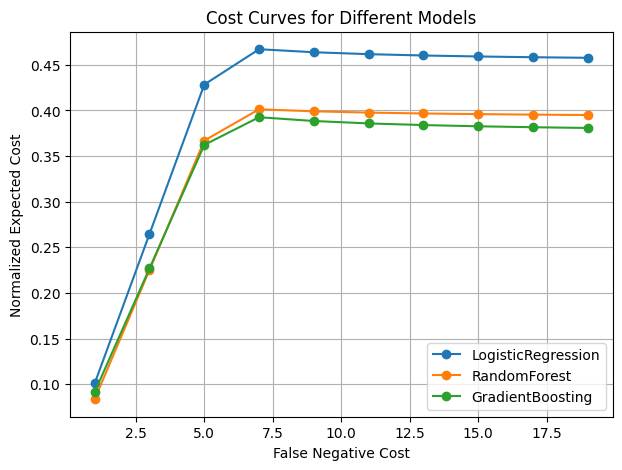

In [80]:
# Step 6: Cost curve computation
fn_cost_values = np.arange(1, 21, 2)  # FN cost from 1 to 20
fp_cost = 1
threshold = 0.5  # fixed for this example

plt.figure(figsize=(7, 5))

for name, mdl in models.items():
    y_prob = mdl.predict_proba(X_test)[:, 1]
    y_pred = (y_prob >= threshold).astype(int)
    cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
    TN, FP, FN, TP = cm.ravel()

    norm_costs = []
    for fn_c in fn_cost_values:
        cost_matrix = np.array([[0, fp_cost],
                                [fn_c, 0]])
        total_cost = (cm * cost_matrix).sum()
        max_cost = max(fp_cost * (TN + FP), fn_c * (FN + TP))  # normalization
        norm_cost = total_cost / max_cost if max_cost > 0 else 0
        norm_costs.append(norm_cost)

    plt.plot(fn_cost_values, norm_costs, marker='o', label=name)

plt.xlabel("False Negative Cost")
plt.ylabel("Normalized Expected Cost")
plt.title("Cost Curves for Different Models")
plt.legend()
plt.grid(True)
plt.show()

---

#### **In-Class Reflection: Exercise Summary**

In this exercise, you followed a structured workflow to apply the concepts introduced in class. Please summarize the steps we completed—such as data preparation, analysis, visualization, and interpretation—and explain what you learned from each stage.  

Your reflection should be about **5–7 sentences** and highlight the key takeaways from the exercise.  

> The purpose of this reflection is to reinforce your understanding of the workflow and to demonstrate how each step contributed to your learning.  

---

In this exercise, an imbalanced binary dataset was created to simulate a realistic classification problem with uneven class distribution. The data was split into training and testing sets, and multiple classifiers were trained, including Logistic Regression, Random Forest, and Gradient Boosting. After training, predictions were generated using a fixed threshold, and a confusion matrix was used to understand the types of classification errors made by each model. A cost matrix was then applied with varying false negative costs to calculate normalized expected cost across different scenarios. These results were plotted as cost curves to visually compare how each model behaves as the cost of missing positive cases increases. The visualization showed that different models perform better under different cost conditions, making it easier to identify which model is most suitable depending on the application. Overall, the exercise demonstrated how cost curves provide a clear and practical way to evaluate models beyond traditional accuracy metrics.

#### **Exercise 24: Performing Cost-Sensitive ROC Analysis**

In this exercise, you will extend standard ROC analysis to include **cost sensitivity**. Instead of only looking at the trade-off between the true positive rate (TPR) and false positive rate (FPR), you will overlay **iso-cost lines** that represent points of equal expected cost for a given cost ratio. This allows you to visualize which parts of the ROC space are optimal under specific cost conditions.

You will:
- Create an imbalanced binary classification dataset.
- Train a classifier and obtain predicted probabilities.
- Plot the ROC curve.
- Add iso-cost lines for different FN/FP cost ratios.
- Interpret which thresholds minimize cost for each scenario.

---

In [81]:
# Exercise 24: Performing Cost-Sensitive ROC Analysis
# ---------------------------------------------------

# Step 1: Imports
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, auc

# Step 2: Create dataset
X, y = make_classification(
    n_samples=3000,
    n_features=20,
    n_informative=8,
    n_redundant=4,
    weights=[0.85, 0.15],
    class_sep=1.2,
    random_state=42
)

# Step 3: Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=42
)

# Step 4: Train model
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

clf = LogisticRegression(max_iter=1000, solver="lbfgs", random_state=42)
clf.fit(X_train_sc, y_train)


LogisticRegression(max_iter=1000, random_state=42)

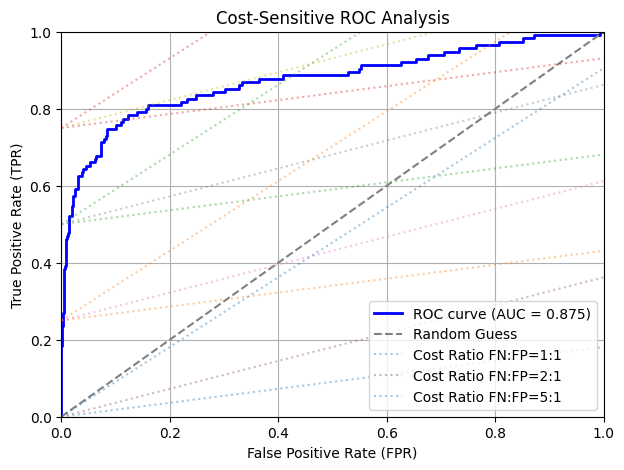

In [82]:
# Step 5: ROC curve
y_prob = clf.predict_proba(X_test_sc)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

# Step 6: Plot ROC curve
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color="blue", lw=2, label=f"ROC curve (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], color="gray", linestyle="--", label="Random Guess")

# Step 7: Add iso-cost lines
cost_ratios = [1, 2, 5]  # FN cost relative to FP cost
p_pos = np.mean(y_test)  # prevalence of positives
p_neg = 1 - p_pos

for c in cost_ratios:
    slope = (c * p_pos) / (p_neg)  # slope from cost ratio
    intercepts = np.linspace(0, 1, 5)
    for i in intercepts:
        x_vals = np.array([0, 1])
        y_vals = slope * x_vals + i
        plt.plot(x_vals, y_vals, linestyle=":", alpha=0.4, label=f"Cost Ratio FN:FP={c}:1" if i == 0 else "")

plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.title("Cost-Sensitive ROC Analysis")
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.legend()
plt.grid(True)
plt.show()


---

#### **In-Class Reflection: Exercise Summary**

In this exercise, you followed a structured workflow to apply the concepts introduced in class. Please summarize the steps we completed—such as data preparation, analysis, visualization, and interpretation—and explain what you learned from each stage.  

Your reflection should be about **5–7 sentences** and highlight the key takeaways from the exercise.  

> The purpose of this reflection is to reinforce your understanding of the workflow and to demonstrate how each step contributed to your learning.  

---

In this exercise, an imbalanced binary classification dataset was created to represent a realistic scenario where one class is much less frequent than the other. The data was split into training and testing sets, and a Logistic Regression model was trained after applying feature scaling to improve performance. Predicted probabilities were then used to generate the ROC curve, which shows the trade-off between the true positive rate and false positive rate across different thresholds. To make the analysis cost-sensitive, iso-cost lines were added for different false negative to false positive cost ratios. These lines helped show how the optimal decision threshold changes depending on how expensive it is to miss positive cases. The visualization made it clear that the best model performance depends not only on AUC but also on the cost structure of the problem. Overall, the exercise demonstrated how ROC analysis can be extended to include real-world cost considerations for better decision-making.

#### **Module 8.7: Data-Driven Error Cost Modeling**

Data-driven error cost modeling involves estimating the costs associated with different types of classification errors directly from historical data or business metrics. This approach helps align model evaluation and decision-making with real-world impacts.

In this sub-module, you will learn how to:  
- Analyze historical outcomes and operational data to quantify the financial or societal costs of false positives and false negatives.  
- Use statistical and economic methods to model error costs dynamically.  
- Incorporate these costs into training objectives and evaluation metrics to build cost-sensitive models.  
- Understand how accurate cost modeling improves decision support and resource allocation.

By grounding error costs in actual data, models become more relevant and effective for practical applications.

---

#### **Exercise 25: Estimating Error Costs from Historical Data**

In this exercise, you will learn how to **quantify error costs** using historical or simulated business data. By analyzing past records of predictions and actual outcomes, along with their associated financial or operational impacts, you can estimate the **average cost of false positives (FP)** and **false negatives (FN)**. These estimates will later be used to guide cost-sensitive evaluation and decision-making.

You will:
- Create or load a dataset containing prediction outcomes, actual labels, and their real-world costs.
- Separate the records into TP, FP, FN, and TN categories.
- Compute the average cost for FP and FN from historical data.
- Summarize the results for use in later cost-sensitive modeling.

---

In [83]:
# Exercise 25: Estimating Error Costs from Historical Data
# ------------------------------------------------------------------

import numpy as np
import pandas as pd

# ---------------------------
# Step 1 — Simulate "historical" outcomes with cost impacts
# ---------------------------
np.random.seed(42)
n = 500

# Simulate actual labels (imbalanced) and baseline predictions
actual = np.random.choice([0, 1], size=n, p=[0.85, 0.15])  # 15% positives
predicted = actual.copy()

# Introduce errors in ~20% of rows to mimic imperfect historical decisions
flip_idx = np.random.choice(np.arange(n), size=int(0.20 * n), replace=False)
predicted[flip_idx] = 1 - predicted[flip_idx]

# Assign per-record cost impact from the historical system:
#   TP/TN: small positive gain (benefit)
#   FP:    operational loss (e.g., unnecessary investigation)
#   FN:    larger loss (e.g., missed case, downstream cost)
cost_impact = np.empty(n, dtype=float)
for i, (a, p) in enumerate(zip(actual, predicted)):
    if a == 1 and p == 1:   # TP
        cost_impact[i] = 200.0
    elif a == 0 and p == 0: # TN
        cost_impact[i] = 50.0
    elif a == 0 and p == 1: # FP
        cost_impact[i] = -1000.0
    else:                   # FN
        cost_impact[i] = -5000.0

# Build the ORIGINAL dataset (no derived columns yet)
df_hist = pd.DataFrame({
    "actual": actual,
    "predicted": predicted,
    "cost_impact": cost_impact
})

# ---------------------------
# Step 2 — Show the ORIGINAL dataset first
# ---------------------------
print("ORIGINAL historical dataset (first 10 rows):")
print(df_hist.head(10))
print(f"\nShape: {df_hist.shape}")
print("\nClass balance (actual):")
print(df_hist["actual"].value_counts(normalize=True).rename("proportion").round(3))
print("\nPredicted balance:")
print(df_hist["predicted"].value_counts(normalize=True).rename("proportion").round(3))


ORIGINAL historical dataset (first 10 rows):
   actual  predicted  cost_impact
0       0          0         50.0
1       1          0      -5000.0
2       0          0         50.0
3       0          0         50.0
4       0          0         50.0
5       0          0         50.0
6       0          0         50.0
7       1          1        200.0
8       0          0         50.0
9       0          0         50.0

Shape: (500, 3)

Class balance (actual):
actual
0    0.834
1    0.166
Name: proportion, dtype: float64

Predicted balance:
predicted
0    0.694
1    0.306
Name: proportion, dtype: float64


In [84]:
# ---------------------------
# Step 3 — Add outcome type (TP / TN / FP / FN)
# ---------------------------
# Vectorized mapping for outcome labels
is_tp = (df_hist["actual"] == 1) & (df_hist["predicted"] == 1)
is_tn = (df_hist["actual"] == 0) & (df_hist["predicted"] == 0)
is_fp = (df_hist["actual"] == 0) & (df_hist["predicted"] == 1)
is_fn = (df_hist["actual"] == 1) & (df_hist["predicted"] == 0)

df_hist["outcome"] = np.select(
    [is_tp, is_tn, is_fp, is_fn],
    ["TP", "TN", "FP", "FN"],
    default="UNK"
)


In [85]:
# ---------------------------
# Step 4 — Compute data-driven error costs
# ---------------------------
# Summary stats by outcome type
summary = (
    df_hist
    .groupby("outcome", as_index=False)
    .agg(
        count=("outcome", "size"),
        avg_cost=("cost_impact", "mean"),
        total_cost=("cost_impact", "sum")
    )
    .sort_values(by="outcome")  # order TP, TN, FP, FN
)

print("\nAverage cost per outcome type (from historical data):")
for _, row in summary.iterrows():
    print(f"  {row['outcome']}: avg=${row['avg_cost']:,.2f} | count={int(row['count'])} | total=${row['total_cost']:,.2f}")



Average cost per outcome type (from historical data):
  FN: avg=$-5,000.00 | count=15 | total=$-75,000.00
  FP: avg=$-1,000.00 | count=85 | total=$-85,000.00
  TN: avg=$50.00 | count=332 | total=$16,600.00
  TP: avg=$200.00 | count=68 | total=$13,600.00


In [86]:
# Convenience: pull FP/FN average costs (often used downstream)
avg_cost_fp = summary.loc[summary["outcome"] == "FP", "avg_cost"].values[0]
avg_cost_fn = summary.loc[summary["outcome"] == "FN", "avg_cost"].values[0]

print(f"\nEstimated average FP cost: ${avg_cost_fp:,.2f}")
print(f"Estimated average FN cost: ${avg_cost_fn:,.2f}")



Estimated average FP cost: $-1,000.00
Estimated average FN cost: $-5,000.00


In [87]:
# Optional: show a compact table for the notebook
summary.reset_index(drop=True)

,outcome,count,avg_cost,total_cost
0,FN,15,-5000.0,-75000.0
1,FP,85,-1000.0,-85000.0
2,TN,332,50.0,16600.0
3,TP,68,200.0,13600.0


---

#### **In-Class Reflection: Exercise Summary**

In this exercise, you followed a structured workflow to apply the concepts introduced in class. Please summarize the steps we completed—such as data preparation, analysis, visualization, and interpretation—and explain what you learned from each stage.  

Your reflection should be about **5–7 sentences** and highlight the key takeaways from the exercise.  

> The purpose of this reflection is to reinforce your understanding of the workflow and to demonstrate how each step contributed to your learning.  

---

In this exercise, a simulated historical dataset was created to represent real-world prediction outcomes along with their associated financial impacts. The data included actual labels, model predictions, and a cost value assigned to each outcome, where false negatives and false positives had higher penalties compared to correct predictions. The dataset was then labeled into TP, TN, FP, and FN categories to clearly separate different types of prediction results. After that, the average and total cost for each outcome type were calculated to estimate real-world error costs directly from data. It was observed that false negatives had the highest average cost, followed by false positives, showing that different errors have very different impacts. These estimated costs can now be used in future models to make more cost-aware decisions. Overall, the exercise demonstrated how historical data can be used to derive meaningful error costs that improve practical decision-making.

#### **Exercise 26: Building a Dynamic Cost Model from Business Metrics**

In this exercise, you’ll build a **data‑driven, dynamic cost model** from business metrics and apply it to classification decisions. Instead of using a single fixed FP/FN cost, you’ll define **per‑instance costs** that depend on operational variables (e.g., investigation cost) and outcome severity (e.g., expected loss if a true positive is missed). You’ll then compute the **expected cost** across thresholds and perform a **sensitivity analysis** to see how the optimal operating point changes when business levers (budgets, penalties) change.

You will:
- Create an imbalanced dataset with an additional **severity** and **investigation_hours** feature to represent business context.
- Define a **dynamic cost function**:  
  - `FP_cost_i = base_fp_cost + hourly_cost * investigation_hours_i`  
  - `FN_cost_i = base_fn_cost * (1 + gamma * severity_i)`
- For thresholds in `[0,1]`, compute **expected total cost** by summing per‑instance FP/FN costs induced by predictions.
- Find the **cost‑minimizing threshold**.
- Run a **sensitivity analysis** over different (base_fp_cost, base_fn_cost, hourly_cost, gamma) settings and compare the optimal thresholds.

---

In [88]:
# Exercise 26: Building a Dynamic Cost Model from Business Metrics
# ---------------------------------------------------------------

import numpy as np
import pandas as pd

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# ---------------------------
# Step 1 — Create a dataset + business-context features
# ---------------------------
# Binary classification with class imbalance (positives are rare/costly)
X, y = make_classification(
    n_samples=4000,
    n_features=12,
    n_informative=6,
    n_redundant=3,
    weights=[0.88, 0.12],   # ~12% positives
    class_sep=1.2,
    random_state=42
)

# Add two business-context features (not used by model directly, but used for costs):
# severity in [0,1] (higher = worse consequence if missed)
# investigation_hours in [0, 4] (operational time spent on a positive flag)
rng = np.random.default_rng(42)
severity = rng.uniform(0, 1, size=X.shape[0])
investigation_hours = rng.uniform(0, 4, size=X.shape[0])

# We'll append these two for record-keeping but keep model training on original features.
# (You could also include them as model features if appropriate.)
X_train, X_test, y_train, y_test, sev_train, sev_test, hrs_train, hrs_test = train_test_split(
    X, y, severity, investigation_hours, test_size=0.25, stratify=y, random_state=42
)

# ---------------------------
# Step 2 — Train a baseline classifier
# ---------------------------
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

clf = LogisticRegression(max_iter=1000, solver="lbfgs", random_state=42)
clf.fit(X_train_sc, y_train)
y_prob = clf.predict_proba(X_test_sc)[:, 1]  # probability for positive class


In [89]:
# ---------------------------
# Step 3 — Define a dynamic cost model (per-instance)
# ---------------------------
def compute_expected_cost(y_true, y_score, threshold,
                          severity_vec,
                          investigation_hours_vec,
                          base_fp_cost=300.0,          # fixed cost per false alarm
                          hourly_cost=75.0,            # staff time per hour
                          base_fn_cost=5000.0,         # base miss cost
                          gamma=2.0):                  # amplifies severity effect on FN
    """
    Return total expected cost at a given threshold with per-instance costs.
    FP_cost_i = base_fp_cost + hourly_cost * investigation_hours_i
    FN_cost_i = base_fn_cost * (1 + gamma * severity_i)
    """
    y_pred = (y_score >= threshold).astype(int)
    # Identify FP and FN
    is_fp = (y_true == 0) & (y_pred == 1)
    is_fn = (y_true == 1) & (y_pred == 0)

    # Per-instance costs
    fp_costs = base_fp_cost + hourly_cost * investigation_hours_vec
    fn_costs = base_fn_cost * (1.0 + gamma * severity_vec)

    total_cost = fp_costs[is_fp].sum() + fn_costs[is_fn].sum()
    return total_cost


In [90]:
# ---------------------------
# Step 4 — Sweep thresholds and find the minimum-cost operating point
# ---------------------------
thresholds = np.linspace(0.0, 1.0, 201)
costs = []

params = dict(
    base_fp_cost=300.0,
    hourly_cost=75.0,
    base_fn_cost=5000.0,
    gamma=2.0
)

for t in thresholds:
    c = compute_expected_cost(y_test, y_prob, t, sev_test, hrs_test, **params)
    costs.append(c)

costs = np.array(costs)
best_idx = np.argmin(costs)
best_threshold = thresholds[best_idx]
best_cost = costs[best_idx]

print("=== Dynamic Cost Model (Single Scenario) ===")
print(f"Best threshold: {best_threshold:.3f}")
print(f"Minimum expected cost: ${best_cost:,.2f}")


=== Dynamic Cost Model (Single Scenario) ===
Best threshold: 0.060
Minimum expected cost: $167,247.24


In [91]:
# ---------------------------
# Step 5 — Sensitivity analysis over business metrics
# ---------------------------
scenarios = [
    # (scenario_name, base_fp_cost, hourly_cost, base_fn_cost, gamma)
    ("Baseline",      300.0,  75.0, 5000.0, 2.0),
    ("Cheaper Ops",   200.0,  50.0, 5000.0, 2.0),
    ("Costly Ops",    400.0, 100.0, 5000.0, 2.0),
    ("Mild FN Loss",  300.0,  75.0, 2500.0, 1.5),
    ("Severe FN Loss",300.0,  75.0, 8000.0, 3.0),
]

rows = []
for name, bfp, hc, bfn, g in scenarios:
    sc_costs = []
    for t in thresholds:
        sc = compute_expected_cost(
            y_test, y_prob, t, sev_test, hrs_test,
            base_fp_cost=bfp, hourly_cost=hc, base_fn_cost=bfn, gamma=g
        )
        sc_costs.append(sc)
    sc_costs = np.array(sc_costs)
    i_min = np.argmin(sc_costs)
    rows.append({
        "Scenario": name,
        "Best Threshold": thresholds[i_min],
        "Min Expected Cost": sc_costs[i_min]
    })

sensitivity = pd.DataFrame(rows)
sensitivity.sort_values(by="Min Expected Cost", inplace=True)
sensitivity.reset_index(drop=True, inplace=True)
sensitivity


,Scenario,Best Threshold,Min Expected Cost
0,Mild FN Loss,0.230,86730.918762
1,Cheaper Ops,0.045,145500.419403
2,Baseline,0.060,167247.237632
3,Costly Ops,0.150,180295.723792
4,Severe FN Loss,0.025,258566.568180


---

#### **In-Class Reflection: Exercise Summary**

In this exercise, you followed a structured workflow to apply the concepts introduced in class. Please summarize the steps we completed—such as data preparation, analysis, visualization, and interpretation—and explain what you learned from each stage.  

Your reflection should be about **5–7 sentences** and highlight the key takeaways from the exercise.  

> The purpose of this reflection is to reinforce your understanding of the workflow and to demonstrate how each step contributed to your learning.  

---

In this exercise, an imbalanced dataset was created along with additional business-related features such as severity and investigation hours to represent real operational conditions. A Logistic Regression model was trained on the dataset, and predicted probabilities were used to evaluate different decision thresholds. A dynamic cost function was defined where false positive and false negative costs varied based on instance-level factors like investigation effort and severity of outcomes. The model was then tested across a range of thresholds to find the point that minimized the total expected cost. It was observed that the optimal threshold was very low, showing that cost-sensitive decisions can significantly differ from standard classification defaults. A sensitivity analysis was also performed by changing business parameters, which showed that the best threshold shifts depending on operational costs and risk levels. Overall, the exercise demonstrated how incorporating real business factors into cost modeling leads to more realistic and practical decision-making.

#### **Exercise 27: Incorporating Data-Driven Costs into Model Evaluation**

In this exercise, you will integrate **data-derived error costs** directly into your model evaluation process. Instead of relying on accuracy or F1 alone, you will compute **expected total cost** as your main evaluation metric and compare multiple classifiers under these real-world cost constraints.

You will:
- Use historical data with estimated FP and FN costs from a prior analysis (or simulate them).
- Train multiple models on a binary classification task.
- Apply the data-driven cost model to each model’s predictions.
- Rank models by **expected cost** instead of accuracy.
- Compare how the rankings differ when switching between accuracy and cost-based evaluation.

---

In [92]:
# Exercise 27: Incorporating Data-Driven Costs into Model Evaluation
# ------------------------------------------------------------------

import numpy as np
import pandas as pd
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# ---------------------------
# Step 1 — Simulate dataset
# ---------------------------
X, y = make_classification(
    n_samples=3000,
    n_features=15,
    n_informative=6,
    n_redundant=4,
    weights=[0.85, 0.15],
    class_sep=1.3,
    random_state=42
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=42
)

# ---------------------------
# Step 2 — Historical data-driven cost estimates
# ---------------------------
# Assume these came from Exercise 25:
avg_cost_fp = -1200.0  # e.g., $1,200 loss per false positive
avg_cost_fn = -4800.0  # e.g., $4,800 loss per false negative

# Convert to positive costs for summing penalties
avg_cost_fp_abs = abs(avg_cost_fp)
avg_cost_fn_abs = abs(avg_cost_fn)

# ---------------------------
# Step 3 — Define models
# ---------------------------
models = {
    "LogisticRegression": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter=1000, solver="lbfgs", random_state=42))
    ]),
    "RandomForest": RandomForestClassifier(n_estimators=300, random_state=42),
    "GradientBoosting": GradientBoostingClassifier(random_state=42)
}


In [93]:
# ---------------------------
# Step 4 — Train models and evaluate cost
# ---------------------------
rows = []
for name, mdl in models.items():
    mdl.fit(X_train, y_train)
    y_pred = mdl.predict(X_test)

    # Confusion matrix layout: [[TN, FP], [FN, TP]]
    cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
    TN, FP, FN, TP = cm.ravel()

    # Calculate total and per-sample expected cost
    total_cost = (FP * avg_cost_fp_abs) + (FN * avg_cost_fn_abs)
    cost_per_sample = total_cost / len(y_test)

    acc = accuracy_score(y_test, y_pred)

    rows.append({
        "Model": name,
        "TN": TN, "FP": FP, "FN": FN, "TP": TP,
        "Accuracy": acc,
        "Total Cost": total_cost,
        "Cost / Sample": cost_per_sample
    })

df_eval = pd.DataFrame(rows)
df_eval = df_eval.sort_values(by="Cost / Sample").reset_index(drop=True)

print("Model Evaluation by Expected Cost:")
print(df_eval)

Model Evaluation by Expected Cost:
                Model   TN  FP  FN   TP  Accuracy  Total Cost  Cost / Sample
0        RandomForest  630   6  11  103  0.977333     60000.0           80.0
1    GradientBoosting  625  11  12  102  0.969333     70800.0           94.4
2  LogisticRegression  623  13  23   91  0.952000    126000.0          168.0


---

#### **In-Class Reflection: Exercise Summary**

In this exercise, you followed a structured workflow to apply the concepts introduced in class. Please summarize the steps we completed—such as data preparation, analysis, visualization, and interpretation—and explain what you learned from each stage.  

Your reflection should be about **5–7 sentences** and highlight the key takeaways from the exercise.  

> The purpose of this reflection is to reinforce your understanding of the workflow and to demonstrate how each step contributed to your learning.  

---

In this exercise, a binary classification dataset was created to simulate a realistic prediction problem with imbalanced classes. The data was split into training and testing sets, and multiple models including Logistic Regression, Random Forest, and Gradient Boosting were trained on the same dataset. Instead of evaluating models using only accuracy, data-driven error costs from earlier analysis were used to assign penalties to false positives and false negatives. Each model’s confusion matrix was analyzed to calculate the total expected cost and cost per sample. It was observed that even though Logistic Regression had relatively high accuracy, it resulted in the highest overall cost compared to the other models. Random Forest performed best in terms of cost, showing that lower accuracy does not always mean worse real-world performance. Overall, the exercise demonstrated how cost-based evaluation can change model rankings and lead to more practical and impactful decisions.

#### **Exercise 28: Training a Model with Data-Derived Class Weights**

In this exercise, you will use **data-derived error costs** to set class weights during model training. By converting historical FP and FN costs into proportional class weights, you can make the model inherently more sensitive to the more costly class, reducing expensive errors without needing post-training threshold tuning.

You will:
- Start with historical FP and FN cost estimates (from Exercise 25 or simulated).
- Convert these costs into normalized class weights.
- Train a cost-sensitive model using `class_weight` in scikit-learn.
- Compare performance metrics and expected cost against a model without class weighting.

---

In [94]:
# Exercise 28: Training a Model with Data-Derived Class Weights
# -------------------------------------------------------------

import numpy as np
import pandas as pd
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.linear_model import LogisticRegression

# ---------------------------
# Step 1 — Simulate dataset
# ---------------------------
X, y = make_classification(
    n_samples=3000,
    n_features=15,
    n_informative=6,
    n_redundant=4,
    weights=[0.85, 0.15],
    class_sep=1.3,
    random_state=42
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=42
)

# ---------------------------
# Step 2 — Historical data-driven cost estimates
# ---------------------------
# Assume values from Exercise 25 (negative sign means loss)
avg_cost_fp = -1200.0  # loss per false positive
avg_cost_fn = -4800.0  # loss per false negative

# Convert to absolute for weighting
avg_cost_fp_abs = abs(avg_cost_fp)
avg_cost_fn_abs = abs(avg_cost_fn)


In [95]:
# ---------------------------
# Step 3 — Convert costs to class weights
# ---------------------------
# Higher FN cost => higher weight for positive class
total = avg_cost_fp_abs + avg_cost_fn_abs
weight_neg = avg_cost_fp_abs / total
weight_pos = avg_cost_fn_abs / total

# Scale so that mean weight = 1 (common practice in scikit-learn)
mean_weight = (weight_neg + weight_pos) / 2
weight_neg_scaled = weight_neg / mean_weight
weight_pos_scaled = weight_pos / mean_weight

class_weights = {0: weight_neg_scaled, 1: weight_pos_scaled}
print("Class weights derived from data-driven costs:", class_weights)


Class weights derived from data-driven costs: {0: 0.4, 1: 1.6}


In [96]:
# ---------------------------
# Step 4 — Train models
# ---------------------------
# Without class weighting
model_no_weight = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=1000, solver="lbfgs", random_state=42))
])
model_no_weight.fit(X_train, y_train)
y_pred_no_weight = model_no_weight.predict(X_test)

# With data-driven class weighting
model_weighted = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=1000, solver="lbfgs", random_state=42, class_weight=class_weights))
])
model_weighted.fit(X_train, y_train)
y_pred_weighted = model_weighted.predict(X_test)


In [97]:
# ---------------------------
# Step 5 — Compare performance
# ---------------------------
def evaluate_model(y_true, y_pred, label):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    TN, FP, FN, TP = cm.ravel()
    total_cost = FP * avg_cost_fp_abs + FN * avg_cost_fn_abs
    cost_per_sample = total_cost / len(y_true)
    print(f"\n=== {label} ===")
    print(classification_report(y_true, y_pred, digits=4))
    print(f"Total Expected Cost: ${total_cost:,.2f}")
    print(f"Cost per Sample: ${cost_per_sample:,.2f}")

evaluate_model(y_test, y_pred_no_weight, "Without Class Weights")
evaluate_model(y_test, y_pred_weighted, "With Data-Derived Class Weights")


=== Without Class Weights ===
              precision    recall  f1-score   support

           0     0.9644    0.9796    0.9719       636
           1     0.8750    0.7982    0.8349       114

    accuracy                         0.9520       750
   macro avg     0.9197    0.8889    0.9034       750
weighted avg     0.9508    0.9520    0.9511       750

Total Expected Cost: $126,000.00
Cost per Sample: $168.00

=== With Data-Derived Class Weights ===
              precision    recall  f1-score   support

           0     0.9869    0.9513    0.9688       636
           1     0.7737    0.9298    0.8446       114

    accuracy                         0.9480       750
   macro avg     0.8803    0.9405    0.9067       750
weighted avg     0.9545    0.9480    0.9499       750

Total Expected Cost: $75,600.00
Cost per Sample: $100.80


---

#### **In-Class Reflection: Exercise Summary**

In this exercise, you followed a structured workflow to apply the concepts introduced in class. Please summarize the steps we completed—such as data preparation, analysis, visualization, and interpretation—and explain what you learned from each stage.  

Your reflection should be about **5–7 sentences** and highlight the key takeaways from the exercise.  

> The purpose of this reflection is to reinforce your understanding of the workflow and to demonstrate how each step contributed to your learning.  

---

In this exercise, a binary classification dataset was created and split into training and testing sets to simulate a real-world imbalanced problem. Historical error costs for false positives and false negatives were used to compute data-driven class weights, giving higher importance to the more expensive class. A Logistic Regression model was first trained without class weights and then retrained using the cost-based weights. Both models were evaluated using classification metrics as well as total expected cost calculated from the confusion matrix. It was observed that while accuracy changed only slightly, the cost-sensitive model significantly reduced the total expected cost. This showed that incorporating business-driven weights during training helps the model focus more on costly errors. Overall, the exercise demonstrated how class weighting based on real costs can improve practical performance even when traditional metrics look similar.

#### **Revised: September 1, 2025**